# LAB 3 - Clasificación

- Jerónimo Vásquez Ponce 202223824
- Jacobo Zarruk Estrada 202223913

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.multioutput import MultiOutputClassifier

from sklearn.metrics import (classification_report, confusion_matrix, f1_score,
                             precision_score, recall_score, accuracy_score)

import warnings
warnings.filterwarnings('ignore')

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## Extracción de los datos

In [2]:
df = pd.read_csv("Datos_Laboratorio3.csv", encoding='latin1', sep=';')
diccionario = pd.read_excel("Diccionario_Laboratorio3.xlsx")

In [3]:
diccionario

,Variable,Tipo_variable,Descripción
0,Edad,Numérica,Edad de la persona en años.
1,Gnereo,Categórica,Género de la persona. Valores permitidos: Feme...
2,Peso,Numérica,Peso corporal de la persona en kilogramos.
3,Altura,Numérica,Altura de la persona en metros.
4,BMI,Numérica,Índice de masa corporal calculado a partir del...
5,Objetivo,Categórica,Objetivo principal de fitness de la persona (G...
6,Condicion_salud,Categórica,Condiciones de salud relevantes que pueden inf...
7,Nivel_Actividad,Categórica,Nivel actual de actividad física habitual del ...
8,Nivel_experiencia,Categórica,Experiencia previa de la persona en entrenamie...
9,Dieta_preferida,Categórica,Preferencia alimentaria general. Valores permi...


## EDA

In [4]:
df.head()

,Edad,Gnereo,Peso,Altura,BMI,Objetivo,Condicion_salud,Nivel_Actividad,Nivel_experiencia,Dieta_preferida,...,Fumador,Cigarrillos_dia,Alcohol,Alcohol_semana,Score_micronutrientes,Ingesta_proteinas,Pasos_dia,Ingesta_agua,Plan_entrenamiento,Plan_nutrición
0,60,Masculino,73.7,1.61,28.43,Resistencia,Hipertension,Bajo,Avanzado,Vegano,...,0,0.0,0,0.0,0.92,182.1,16485,2.49,Medio,Sin plan
1,17,Femenino,121.0,1.97,31.18,Resistencia,Enfermedad corazon,Moderado,Principiante,Vegetariano,...,0,0.0,0,0.0,0.76,167.7,14256,2.04,Ninguno,Sin plan
2,43,Masculino,110.0,1.52,47.61,General,Ninguno,Bajo,Principiante,No-Vegetariano,...,0,0.0,0,0.0,0.34,104.9,3050,2.53,Bajo,Basico
3,49,Otro,73.6,1.96,19.16,General,Ninguno,Moderado,Principiante,No-Vegetariano,...,0,0.0,0,0.0,0.71,59.5,2264,3.36,Ninguno,Sin plan
4,53,Femenino,80.8,1.76,26.08,Resistencia,Hipertension,Alto,Principiante,Pescetariano,...,1,8.7,0,0.0,0.98,51.1,12774,1.90,Medio,Sin plan


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9698 entries, 0 to 9697
Data columns (total 26 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Edad                     9698 non-null   int64  
 1   Gnereo                   9698 non-null   str    
 2   Peso                     9687 non-null   float64
 3   Altura                   9698 non-null   float64
 4   BMI                      9698 non-null   float64
 5   Objetivo                 9698 non-null   str    
 6   Condicion_salud          9698 non-null   str    
 7   Nivel_Actividad          9698 non-null   str    
 8   Nivel_experiencia        9698 non-null   str    
 9   Dieta_preferida          9698 non-null   str    
 10  Horas_sueño              9698 non-null   float64
 11  Entrenamiento_preferido  9698 non-null   str    
 12  Cantidad_equipo          9698 non-null   int64  
 13  Tiempo_disponible        9698 non-null   int64  
 14  Tiene_alergia            9698 non-n

In [6]:
df.describe()

,Edad,Peso,Altura,BMI,Horas_sueño,Cantidad_equipo,Tiempo_disponible,Tiene_alergia,Problemas_digestivos,Fumador,Cigarrillos_dia,Alcohol,Alcohol_semana,Score_micronutrientes,Ingesta_proteinas,Pasos_dia,Ingesta_agua
count,9698.000000,9687.000000,9698.000000,9698.000000,9698.000000,9698.000000,9698.000000,9698.000000,9698.000000,9698.000000,9698.000000,9698.000000,9698.000000,9698.000000,9698.000000,9698.000000,9698.000000
mean,45.112601,92.622515,1.775047,30.131391,7.004382,2.988039,67.194061,0.201588,0.153846,0.227366,2.172252,0.285317,3.778841,0.500115,129.997360,9765.936482,2.748532
std,17.641045,27.383913,0.158754,10.605675,1.449454,2.018493,30.839475,0.401207,0.360820,0.419153,4.624756,0.451588,7.023263,0.289062,51.981874,4762.152079,1.015342
min,15.000000,45.000000,1.500000,10.930000,0.000000,0.000000,15.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,40.000000,200.000000,1.000000
25%,30.000000,68.800000,1.640000,21.620000,5.800000,1.000000,40.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.250000,85.000000,5608.250000,1.860000
50%,45.000000,92.600000,1.780000,29.190000,7.000000,3.000000,67.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.500000,129.950000,9718.000000,2.760000
75%,61.000000,116.500000,1.910000,37.060000,8.200000,5.000000,94.000000,0.000000,0.000000,0.000000,0.000000,1.000000,4.300000,0.750000,175.200000,13953.000000,3.620000
max,75.000000,140.000000,2.050000,62.090000,23.000000,6.000000,120.000000,1.000000,1.000000,1.000000,18.000000,1.000000,25.000000,1.000000,220.000000,17996.000000,4.500000


In [7]:
df.describe(include='object')

,Gnereo,Objetivo,Condicion_salud,Nivel_Actividad,Nivel_experiencia,Dieta_preferida,Entrenamiento_preferido,Plan_entrenamiento,Plan_nutrición
count,9698,9698,9698,9698,9698,9698,9698,9698,9698
unique,3,5,7,3,3,5,6,4,4
top,Femenino,Ganancia muscular,Ninguno,Moderado,Intermedio,No-Vegetariano,Funcional,Ninguno,Balanceado
freq,4719,2757,6030,3594,4100,2456,1666,3807,4297


In [8]:
df.shape

(9698, 26)

### Reporte de calidad de los datos

In [9]:
def reporte_calidad(df):

    reporte_de_cualidad = {
        'Total datos': len(df),
        'Datos duplicados': df.duplicated().sum(),
        'Valores nulos': df.isnull().sum().to_dict(),
        'Tipos de datos': df.dtypes.astype(str).to_dict(),
    }

    return reporte_de_cualidad

reporte_calidad(df)

{'Total datos': 9698,
 'Datos duplicados': np.int64(0),
 'Valores nulos': {'Edad': 0,
  'Gnereo': 0,
  'Peso': 11,
  'Altura': 0,
  'BMI': 0,
  'Objetivo': 0,
  'Condicion_salud': 0,
  'Nivel_Actividad': 0,
  'Nivel_experiencia': 0,
  'Dieta_preferida': 0,
  'Horas_sueño': 0,
  'Entrenamiento_preferido': 0,
  'Cantidad_equipo': 0,
  'Tiempo_disponible': 0,
  'Tiene_alergia': 0,
  'Problemas_digestivos': 0,
  'Fumador': 0,
  'Cigarrillos_dia': 0,
  'Alcohol': 0,
  'Alcohol_semana': 0,
  'Score_micronutrientes': 0,
  'Ingesta_proteinas': 0,
  'Pasos_dia': 0,
  'Ingesta_agua': 0,
  'Plan_entrenamiento': 0,
  'Plan_nutrición': 0},
 'Tipos de datos': {'Edad': 'int64',
  'Gnereo': 'str',
  'Peso': 'float64',
  'Altura': 'float64',
  'BMI': 'float64',
  'Objetivo': 'str',
  'Condicion_salud': 'str',
  'Nivel_Actividad': 'str',
  'Nivel_experiencia': 'str',
  'Dieta_preferida': 'str',
  'Horas_sueño': 'float64',
  'Entrenamiento_preferido': 'str',
  'Cantidad_equipo': 'int64',
  'Tiempo_dispon

### Análisis de variables categóricas

In [10]:
categoricas = df.select_dtypes(include='object').columns.tolist()
for col in categoricas:
    print(f"\n=== {col} ===")
    print(df[col].value_counts())


=== Gnereo ===
Gnereo
Femenino     4719
Masculino    4611
Otro          368
Name: count, dtype: int64

=== Objetivo ===
Objetivo
Ganancia muscular    2757
Perdida grasa        2594
General              2220
Resistencia          2123
grasa                   4
Name: count, dtype: int64

=== Condicion_salud ===
Condicion_salud
Ninguno               6030
Hipertension           814
Lesion                 764
Asma                   745
Diabetes               511
Enfermedad corazon     497
PCOS                   337
Name: count, dtype: int64

=== Nivel_Actividad ===
Nivel_Actividad
Moderado    3594
Bajo        3326
Alto        2778
Name: count, dtype: int64

=== Nivel_experiencia ===
Nivel_experiencia
Intermedio      4100
Principiante    3608
Avanzado        1990
Name: count, dtype: int64

=== Dieta_preferida ===
Dieta_preferida
No-Vegetariano    2456
Vegano            2426
Pescetariano      2403
Vegetariano       2402
Animal              11
Name: count, dtype: int64

=== Entrenamiento_prefe

### Distribución de las variables numéricas

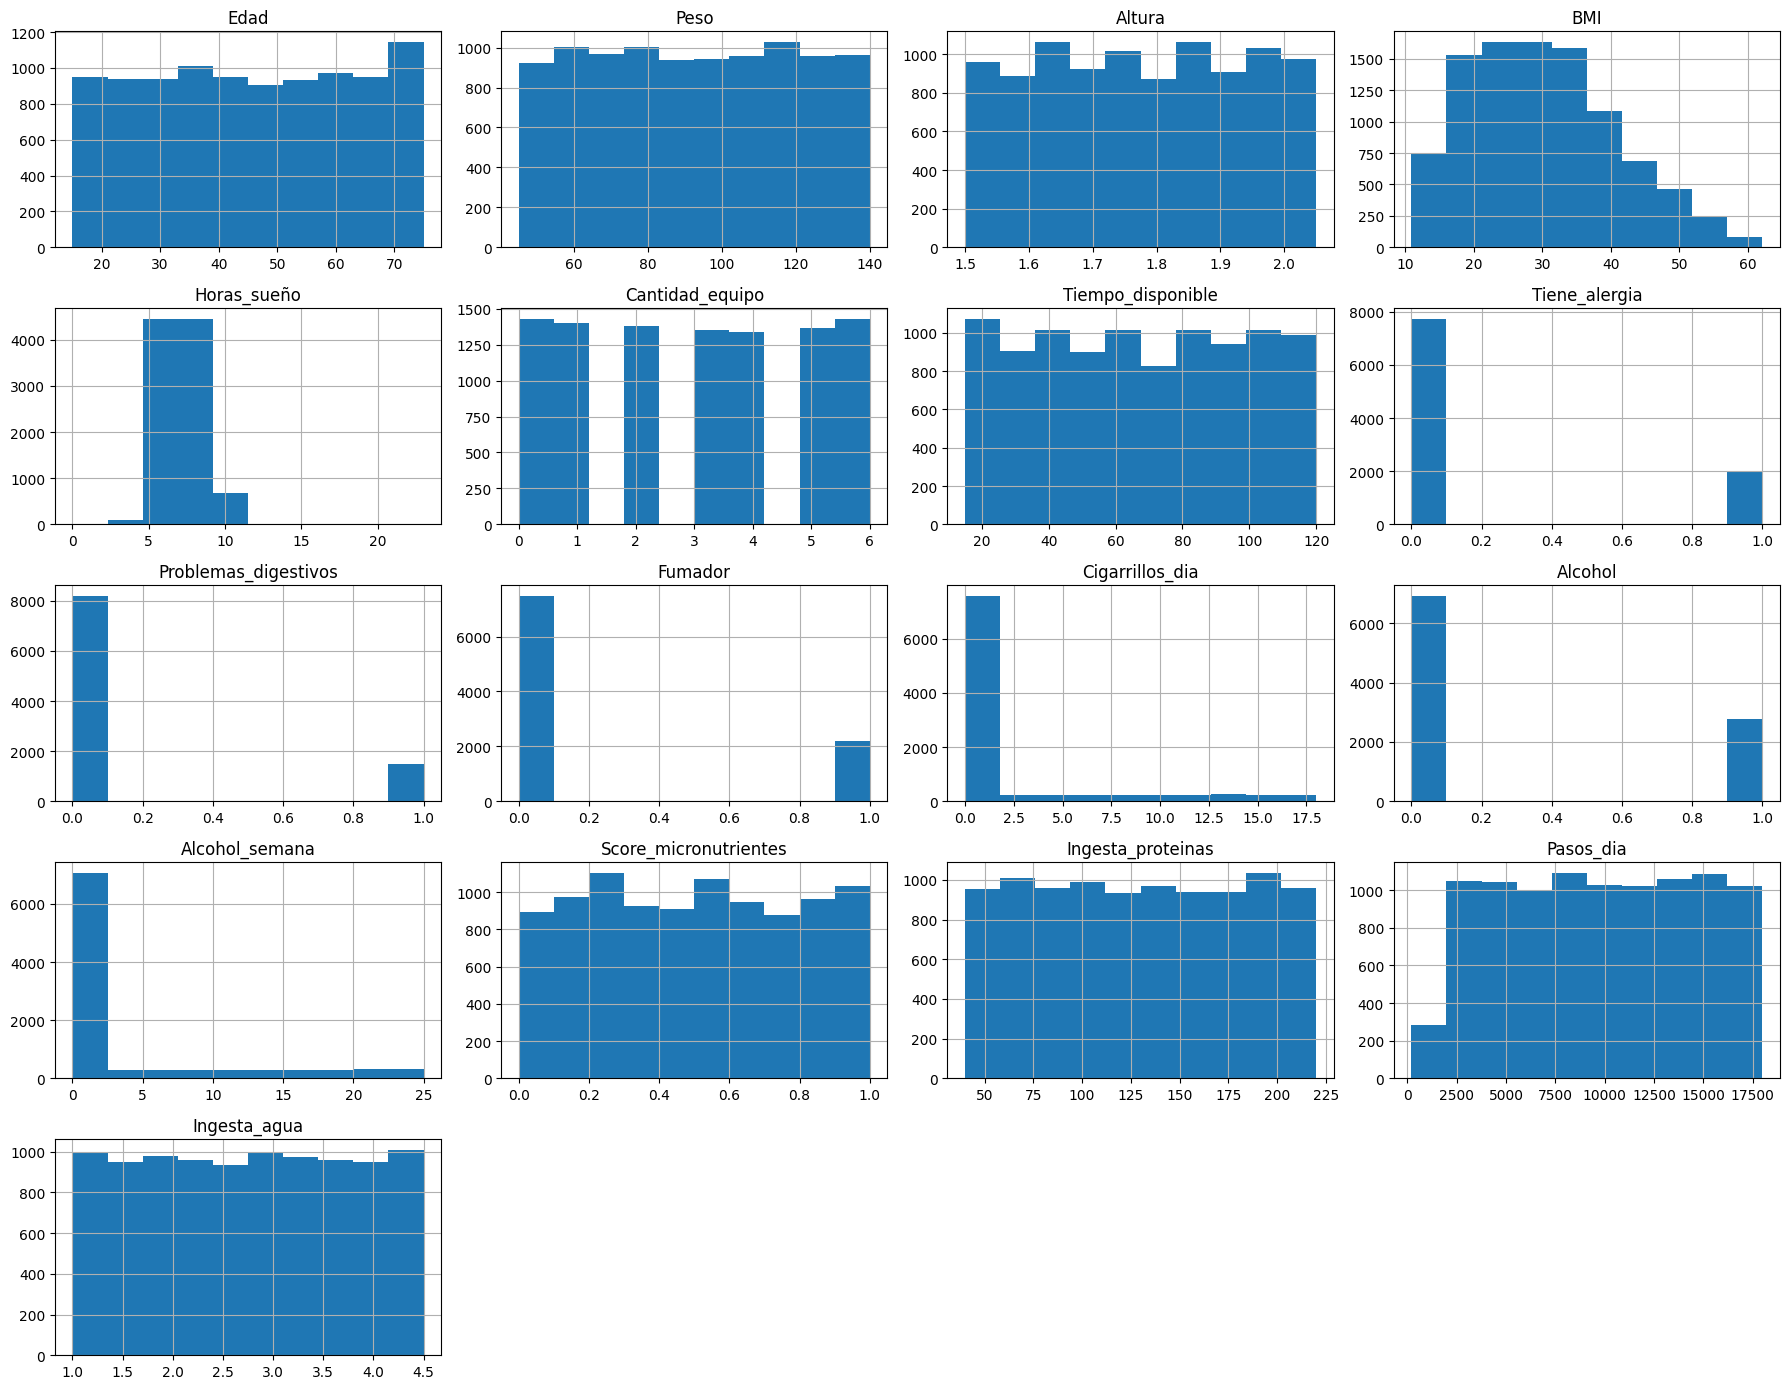

In [11]:
df.hist(figsize=(18,14))
plt.tight_layout()
plt.show()

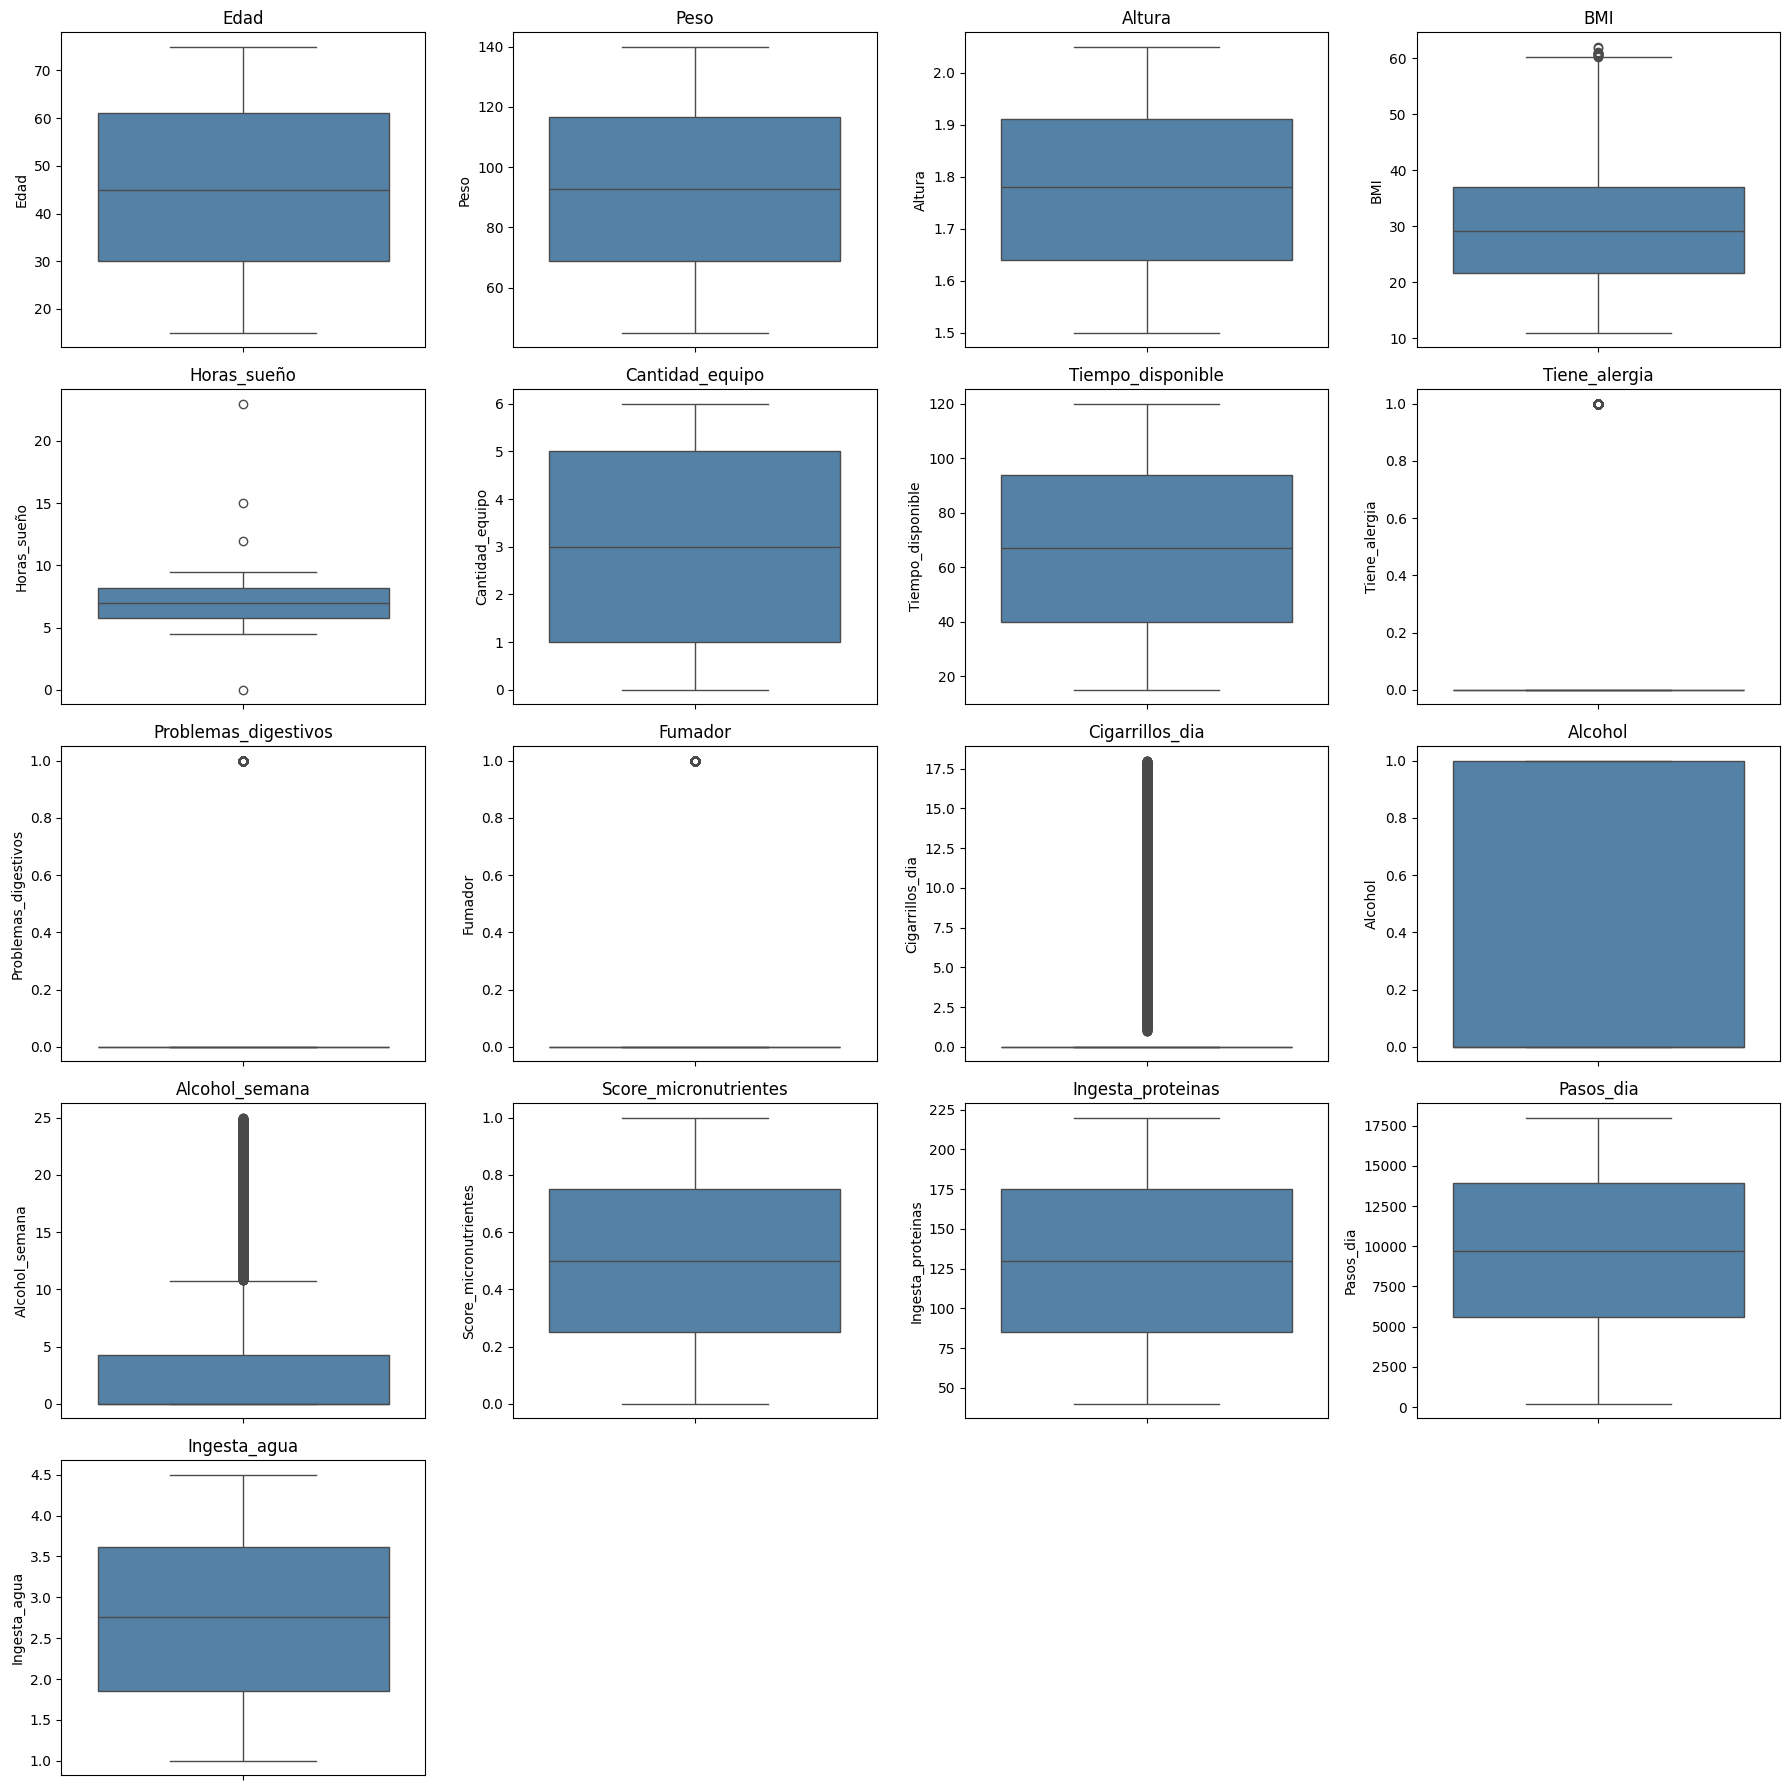

In [12]:
fig, axes = plt.subplots(5, 4, figsize=(18, 18))
numericas = df.select_dtypes(include='number').columns.tolist()
for i, col in enumerate(numericas):
    ax = axes[i//4, i%4]
    sns.boxplot(y=df[col], ax=ax, color='steelblue')
    ax.set_title(col)
for j in range(len(numericas), 20):
    axes[j//4, j%4].axis('off')
plt.tight_layout()
plt.show()

### Identificación de outliers

In [13]:
def identificar_outliers(df, columna):

    Q1 = df[columna].quantile(0.25)
    Q3 = df[columna].quantile(0.75)
    IQR = Q3 - Q1

    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR

    mask_outliers = (df[columna] < limite_inferior) | (df[columna] > limite_superior)
    indices_outliers = df[mask_outliers].index.tolist()
    outliers_df = df.loc[indices_outliers]

    limites = {
        'Q1': Q1,
        'Q3': Q3,
        'IQR': IQR,
        'limite_inferior': limite_inferior,
        'limite_superior': limite_superior
    }

    return indices_outliers, outliers_df, limites

In [14]:
def reporte_outliers(df):
    resultados = []

    for columna in df.select_dtypes(include='number').columns:
        indices, outliers, limites = identificar_outliers(df, columna)

        por_debajo = (df[columna] < limites['limite_inferior']).sum()
        por_encima = (df[columna] > limites['limite_superior']).sum()

        resultados.append({
            'columna': columna,
            'total Outliers': len(indices),
            'por debajo': por_debajo,
            'por encima': por_encima,
            'limite Inferior': round(limites['limite_inferior'], 2),
            'limite Superior': round(limites['limite_superior'], 2)
        })

    return pd.DataFrame(resultados)

reporte_outliers(df)

,columna,total Outliers,por debajo,por encima,limite Inferior,limite Superior
0,Edad,0,0,0,-16.50,107.50
1,Peso,0,0,0,-2.75,188.05
2,Altura,0,0,0,1.23,2.32
3,BMI,12,0,12,-1.54,60.22
4,Horas_sueño,4,1,3,2.20,11.80
5,Cantidad_equipo,0,0,0,-5.00,11.00
6,Tiempo_disponible,0,0,0,-41.00,175.00
7,Tiene_alergia,1955,0,1955,0.00,0.00
8,Problemas_digestivos,1492,0,1492,0.00,0.00
9,Fumador,2205,0,2205,0.00,0.00


### Distribución de las variables objetivo

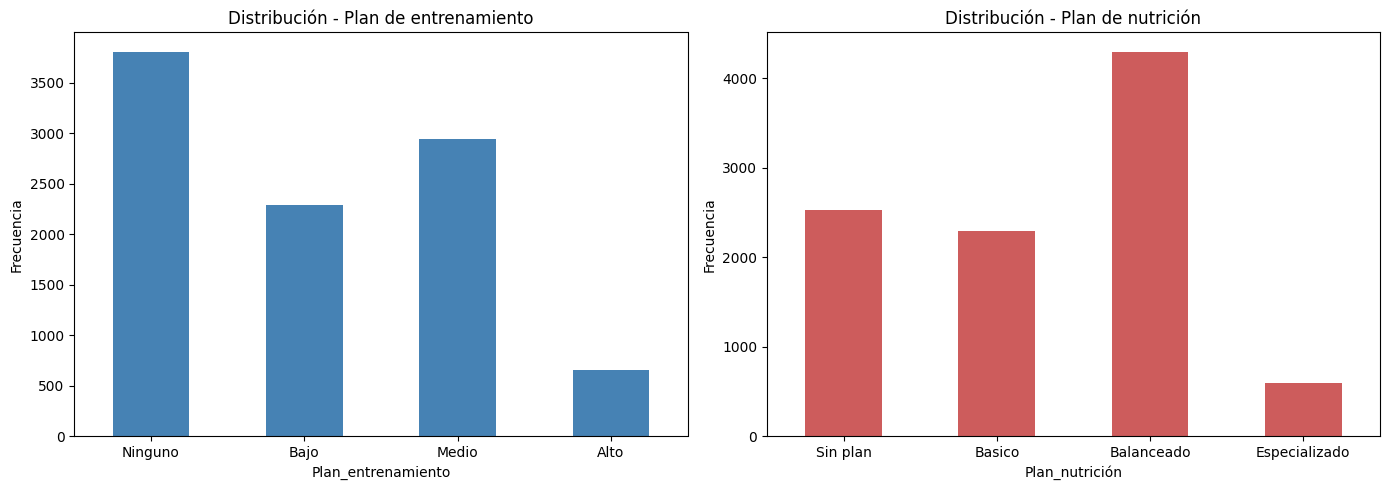

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

orden_ent = ['Ninguno', 'Bajo', 'Medio', 'Alto']
df['Plan_entrenamiento'].value_counts().reindex(orden_ent).plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Distribución - Plan de entrenamiento')
axes[0].set_ylabel('Frecuencia')
axes[0].tick_params(axis='x', rotation=0)

orden_nut = ['Sin plan', 'Basico', 'Balanceado', 'Especializado']
df['Plan_nutrición'].value_counts().reindex(orden_nut).plot(kind='bar', ax=axes[1], color='indianred')
axes[1].set_title('Distribución - Plan de nutrición')
axes[1].set_ylabel('Frecuencia')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

In [16]:
print("Plan_entrenamiento (%):")
print((df['Plan_entrenamiento'].value_counts(normalize=True)*100).round(2))
print("\nPlan_nutrición (%):")
print((df['Plan_nutrición'].value_counts(normalize=True)*100).round(2))

Plan_entrenamiento (%):
Plan_entrenamiento
Ninguno    39.26
Medio      30.37
Bajo       23.61
Alto        6.76
Name: proportion, dtype: float64

Plan_nutrición (%):
Plan_nutrición
Balanceado       44.31
Sin plan         26.01
Basico           23.58
Especializado     6.10
Name: proportion, dtype: float64


### Correlaciones entre variables numéricas

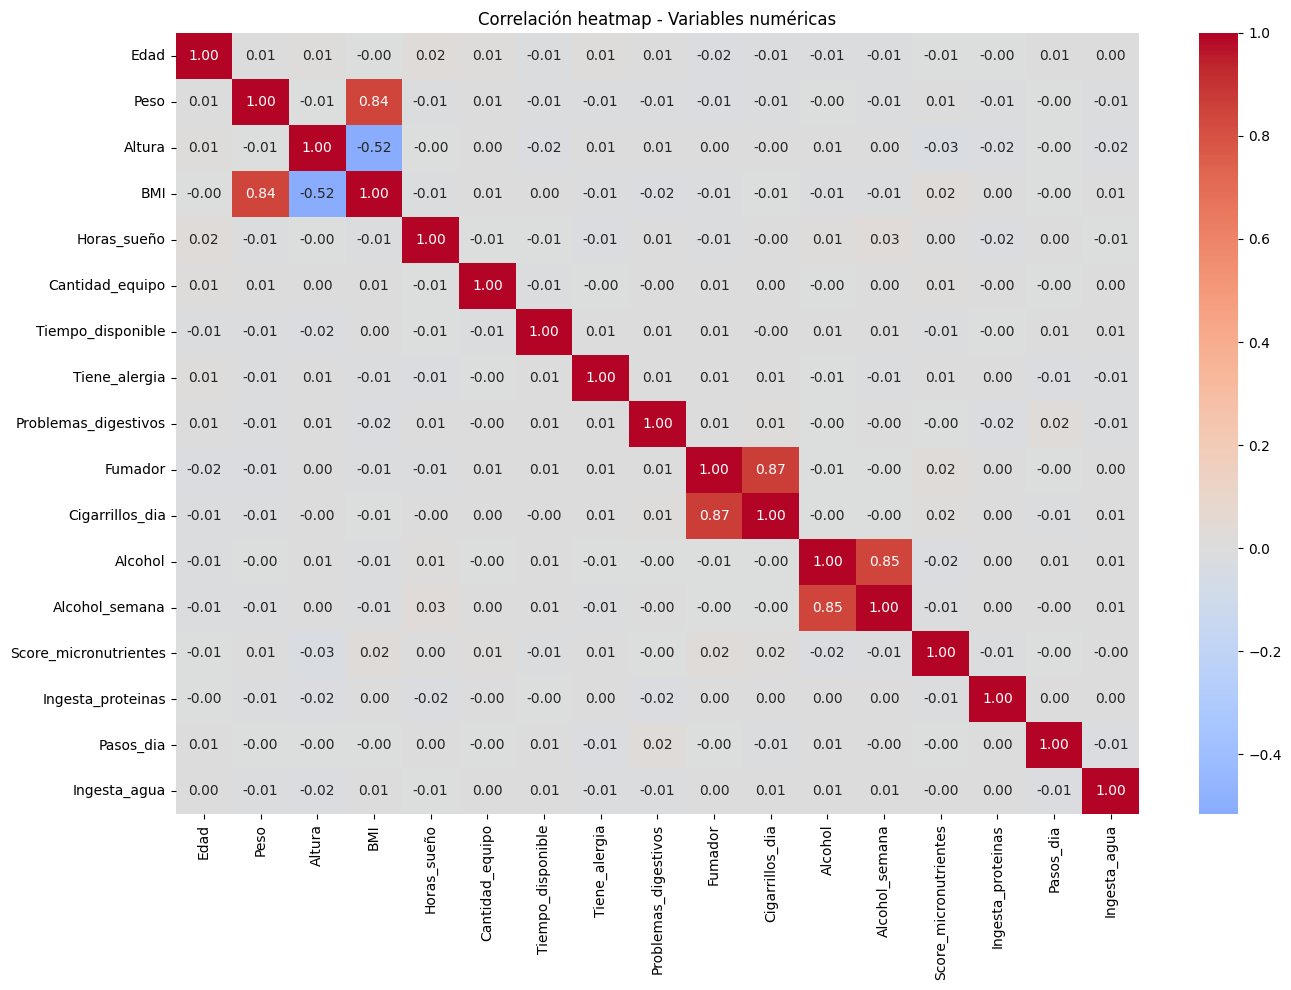

In [17]:
plt.figure(figsize=(14, 10))
corr_numeric = df.corr(numeric_only=True)
sns.heatmap(corr_numeric, annot=True, cmap='coolwarm', fmt='.2f', center=0)
plt.title('Correlación heatmap - Variables numéricas')
plt.tight_layout()
plt.show()

### Relación entre variables categóricas y los objetivos

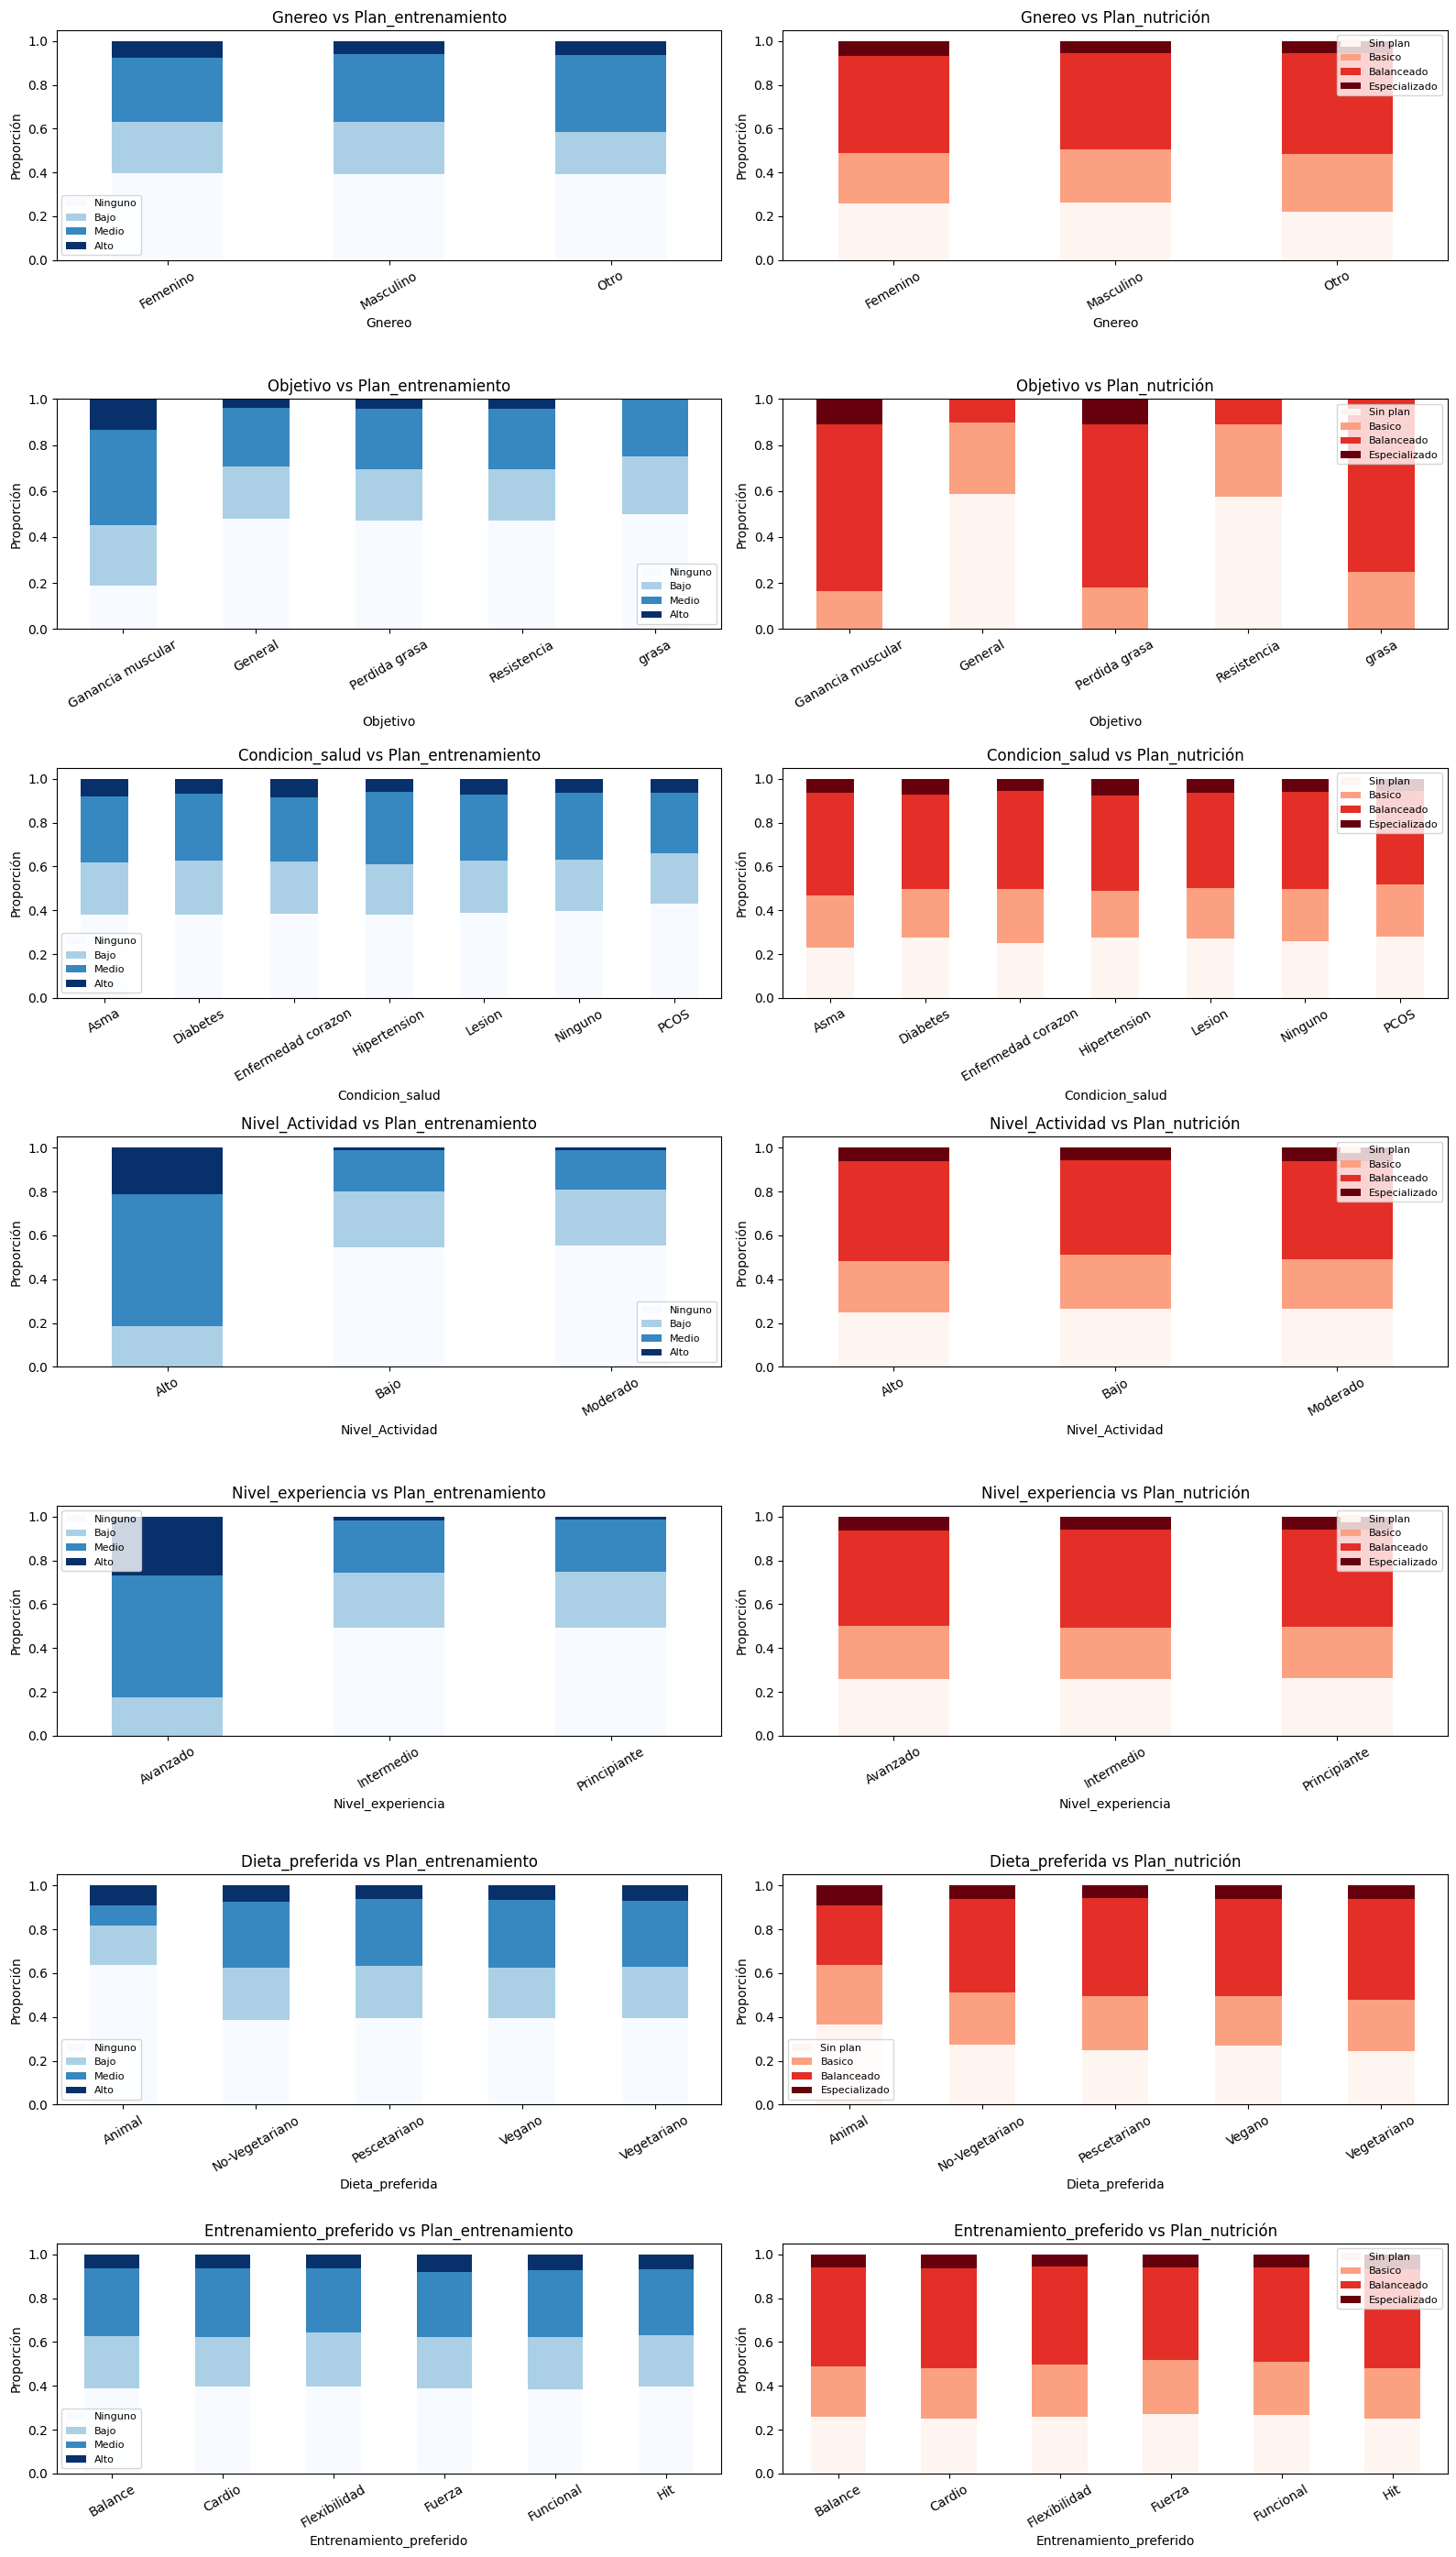

In [18]:
categoricas_features = ['Gnereo','Objetivo','Condicion_salud','Nivel_Actividad',
                        'Nivel_experiencia','Dieta_preferida','Entrenamiento_preferido']

fig, axes = plt.subplots(len(categoricas_features), 2, figsize=(16, 4*len(categoricas_features)))
for i, col in enumerate(categoricas_features):
    ct1 = pd.crosstab(df[col], df['Plan_entrenamiento'], normalize='index')
    ct1 = ct1.reindex(columns=['Ninguno', 'Bajo', 'Medio', 'Alto'])
    ct1.plot(kind='bar', stacked=True, ax=axes[i,0], colormap='Blues')
    axes[i,0].set_title(f'{col} vs Plan_entrenamiento')
    axes[i,0].set_ylabel('Proporción')
    axes[i,0].legend(fontsize=8)
    axes[i,0].tick_params(axis='x', rotation=30)

    ct2 = pd.crosstab(df[col], df['Plan_nutrición'], normalize='index')
    ct2 = ct2.reindex(columns=['Sin plan', 'Basico', 'Balanceado', 'Especializado'])
    ct2.plot(kind='bar', stacked=True, ax=axes[i,1], colormap='Reds')
    axes[i,1].set_title(f'{col} vs Plan_nutrición')
    axes[i,1].set_ylabel('Proporción')
    axes[i,1].legend(fontsize=8)
    axes[i,1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

### Relación entre variables numéricas y los objetivos

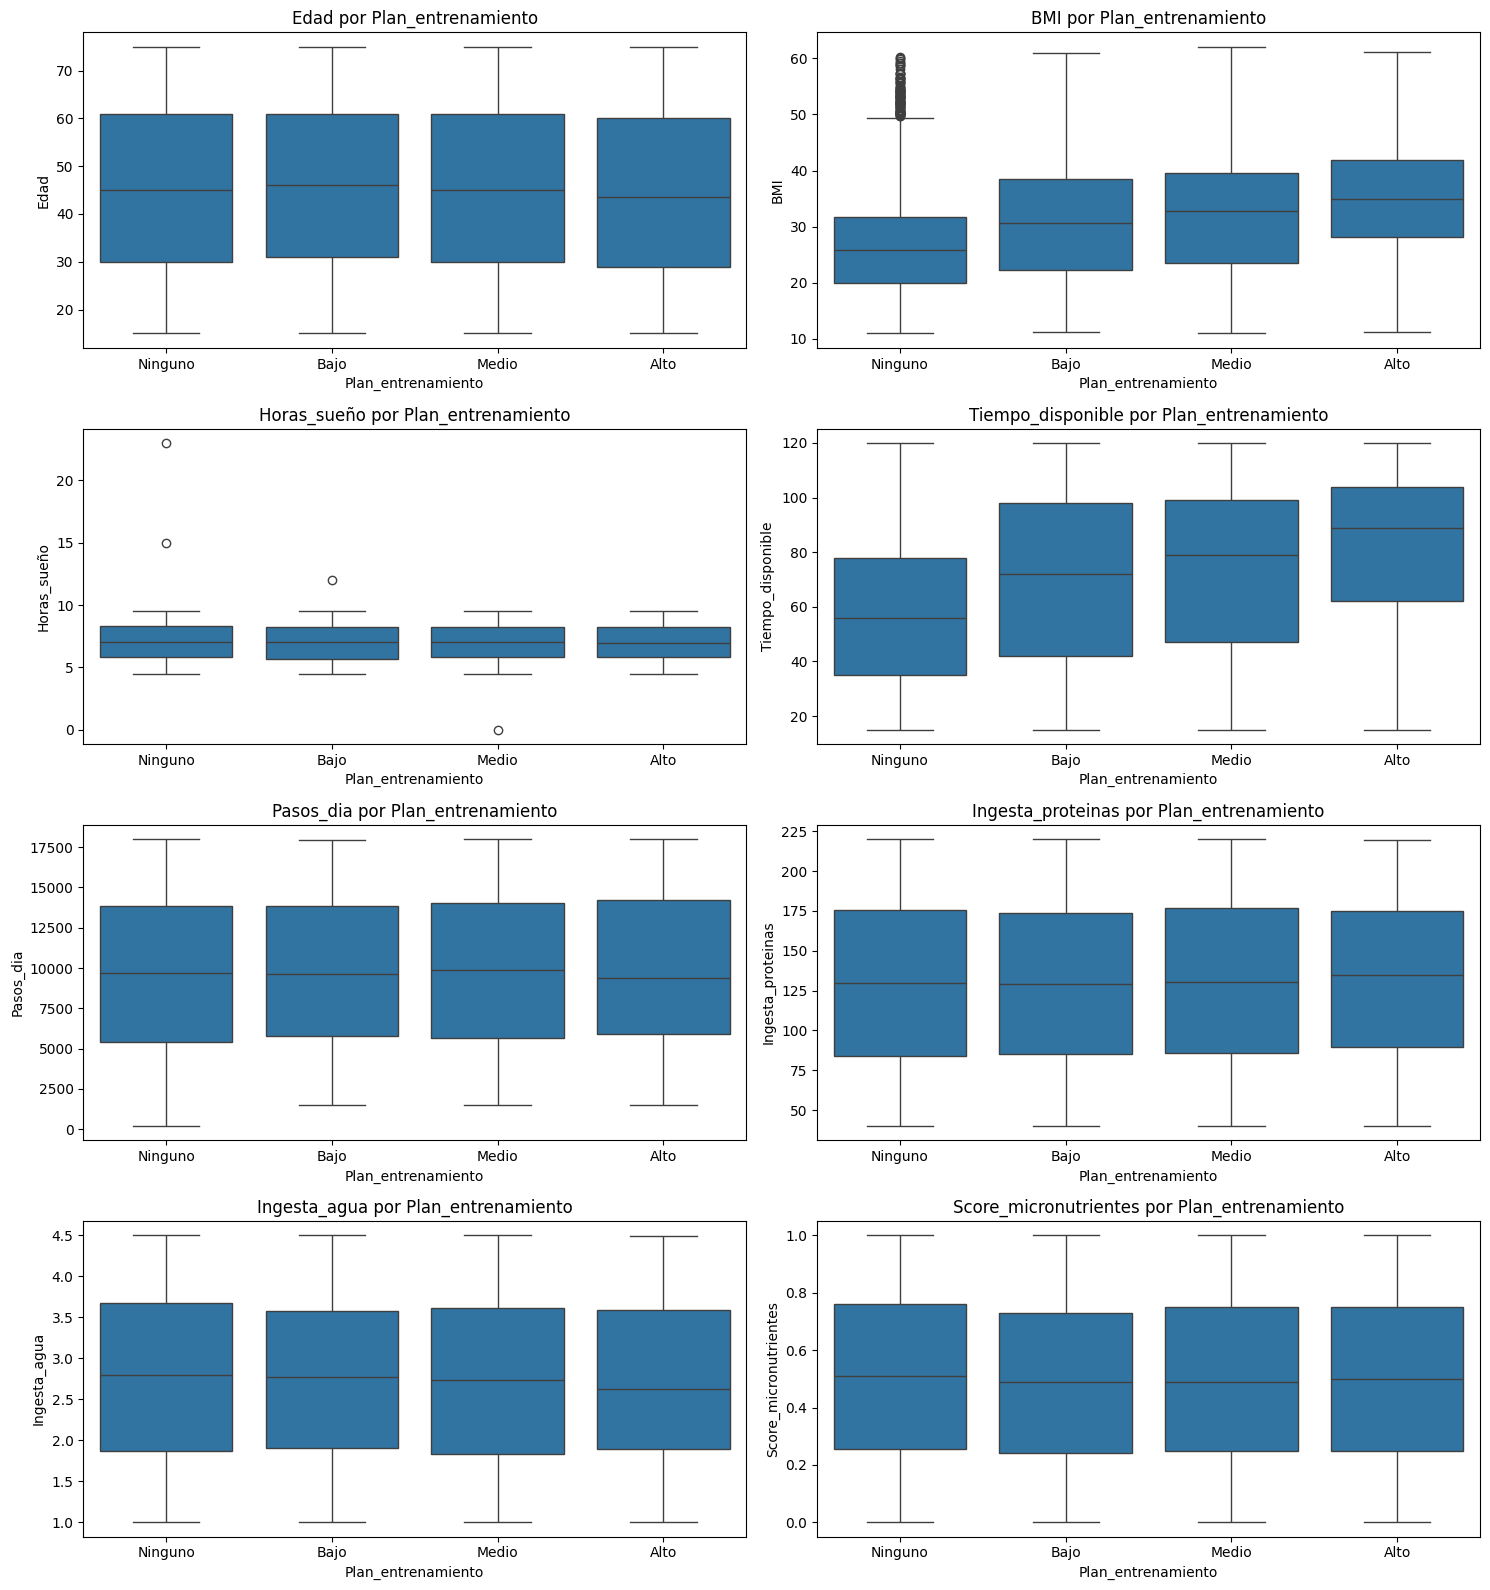

In [19]:
num_vars_interes = ['Edad','BMI','Horas_sueño','Tiempo_disponible','Pasos_dia',
                    'Ingesta_proteinas','Ingesta_agua','Score_micronutrientes']

fig, axes = plt.subplots(4, 2, figsize=(15, 16))
for i, col in enumerate(num_vars_interes):
    sns.boxplot(data=df, x='Plan_entrenamiento', y=col, ax=axes[i//2, i%2],
                order=['Ninguno','Bajo','Medio','Alto'])
    axes[i//2, i%2].set_title(f'{col} por Plan_entrenamiento')
plt.tight_layout()
plt.show()

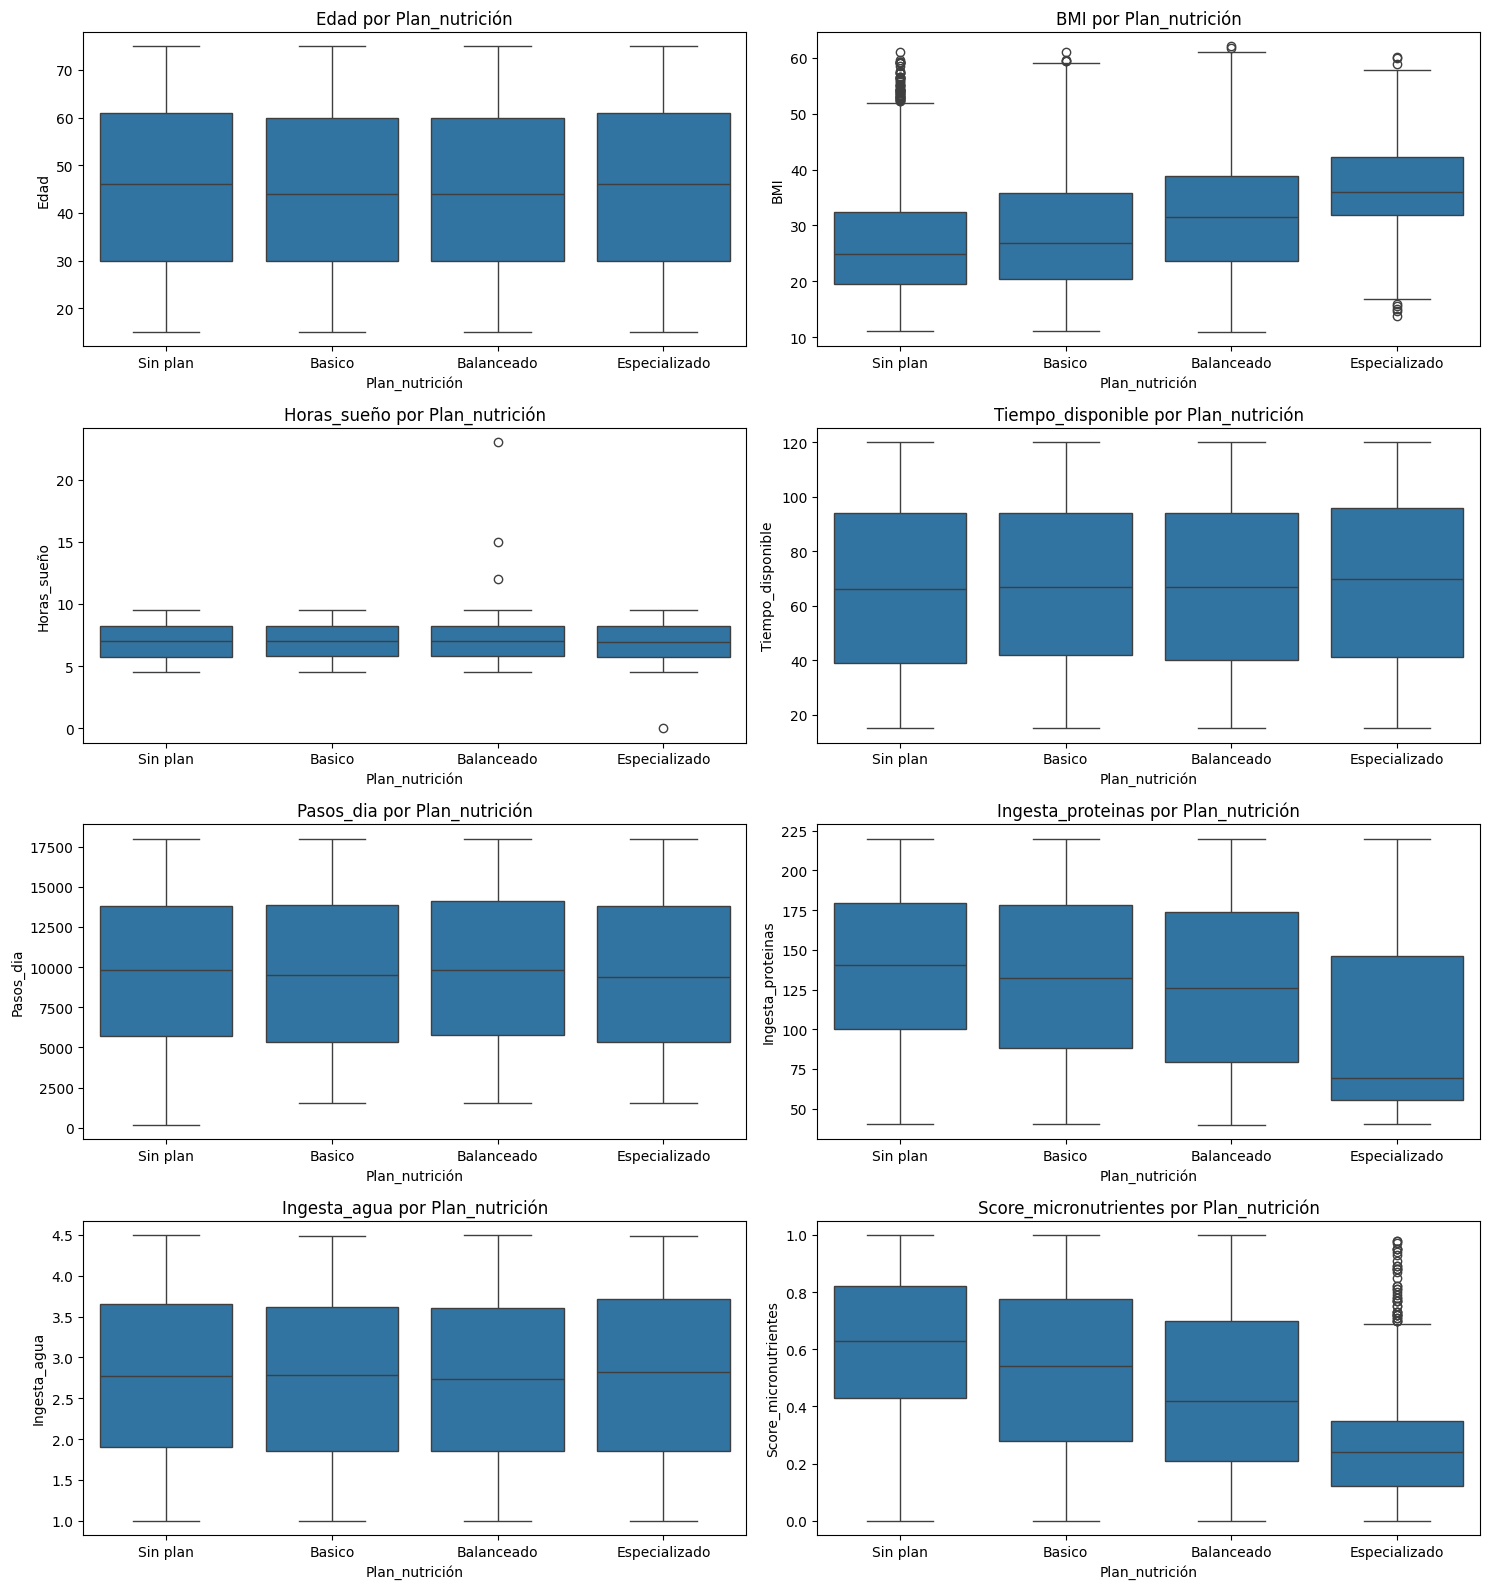

In [20]:
fig, axes = plt.subplots(4, 2, figsize=(15, 16))
for i, col in enumerate(num_vars_interes):
    sns.boxplot(data=df, x='Plan_nutrición', y=col, ax=axes[i//2, i%2],
                order=['Sin plan','Basico','Balanceado','Especializado'])
    axes[i//2, i%2].set_title(f'{col} por Plan_nutrición')
plt.tight_layout()
plt.show()

## Análisis y Reporte de calidad de datos, outliers y correlaciones

### 1. Descripción general del conjunto de datos

El conjunto de datos analizado contiene 9698 registros y 26 columnas, las cuales incluyen 17 variables numéricas y 9 variables categóricas (7 predictoras categóricas más las 2 variables objetivo). No se identificaron registros duplicados.

Las variables objetivo son:
- **Plan_entrenamiento**: 4 clases (Ninguno, Bajo, Medio, Alto).
- **Plan_nutrición**: 4 clases (Sin plan, Basico, Balanceado, Especializado).

---

### 2. Calidad de los datos

El análisis de calidad se realizó evaluando: completitud, unicidad, consistencia y validez.

#### 2.1 Completitud

El análisis de completitud evidencia la presencia de valores nulos únicamente en la variable **Peso** (11 valores nulos). El resto de variables no presenta datos faltantes, lo cual es una señal positiva para la calidad general del dataset.

#### 2.2 Unicidad

No se identificaron registros duplicados dentro del conjunto de datos, lo que indica que cada fila corresponde a un usuario único.

#### 2.3 Consistencia

El análisis de consistencia revela varios problemas en los valores categóricos:

- **Objetivo**: El diccionario de datos especifica 4 categorías (Ganancia muscular, General, Perdida grasa, Resistencia), pero en el dataset aparece una categoría adicional llamada **'grasa'** (4 registros), que probablemente corresponde a un error de captura de 'Perdida grasa'.
- **Dieta_preferida**: El diccionario especifica 4 categorías (No-Vegetariano, Pescetariano, Vegano, Vegetariano), pero en el dataset aparece el valor **'Animal'** (11 registros), que no está definido en el diccionario.
- **Gnereo**: El nombre de la variable presenta un error ortográfico respecto a 'Género'.
- **Plan_nutrición**: El diccionario especifica 'Básico' y 'Especializadoo', mientras que en el dataset aparecen 'Basico' (sin tilde) y 'Especializado' (sin la doble 'o'). En este caso los valores del dataset son los que tienen coherencia ortográfica y se mantienen.
- **Horas_sueño**: La unidad es horas por día, pero en el dataset se observan valores de 0 y de hasta 23 horas, lo cual es fisiológicamente inviable.

Estos problemas requieren un proceso de estandarización previo a la modelación.

#### 2.4 Validez

Se identificaron valores que no son válidos desde el punto de vista lógico o fisiológico:

- Horas de sueño iguales a 0 o superiores a 12 se consideran no válidas para un patrón de sueño regular.
- Las categorías 'grasa' y 'Animal' son inconsistentes con el diccionario de datos.

---

### 3. Análisis de outliers

El análisis de valores atípicos mediante el método IQR muestra lo siguiente:

- **Horas_sueño**: presenta outliers en los extremos (valores de 0 y valores superiores a 12 horas), los cuales se consideran no válidos.
- **Cigarrillos_dia** y **Alcohol_semana**: presentan una distribución fuertemente sesgada a la derecha, con una gran concentración de ceros (personas que no fuman ni beben) y pocos valores altos. Los valores altos en este caso no son errores, sino casos reales de personas con alto consumo, por lo que no se tratarán como outliers a corregir.
- El resto de variables numéricas (Edad, Peso, Altura, BMI, Pasos_dia, Ingesta_agua, Score_micronutrientes, Ingesta_proteinas, Tiempo_disponible, Cantidad_equipo) no presenta outliers significativos, o los presentes parecen ser variaciones naturales de la población.

---

### 4. Análisis de correlaciones y relaciones con la variable objetivo

El heatmap de correlaciones numéricas muestra que las variables están poco correlacionadas entre sí (ausencia de multicolinealidad fuerte), excepto por la relación lógica entre Peso, Altura y BMI, y entre Fumador/Cigarrillos_dia y Alcohol/Alcohol_semana.

El análisis bivariado entre las variables categóricas y las variables objetivo (mediante tablas de contingencia normalizadas) evidencia que:

- **Nivel_Actividad**, **Nivel_experiencia** y **Objetivo** muestran una fuerte relación con Plan_entrenamiento: los niveles altos de actividad y experiencia tienden a asociarse a planes de entrenamiento de mayor intensidad.
- **Condicion_salud** y **Dieta_preferida** parecen tener relación con Plan_nutrición, aunque más débil.
- Variables como **Gnereo** muestran poca discriminación entre clases de ambos objetivos.

Por su parte, las variables numéricas analizadas mediante boxplots por clase objetivo muestran que **Pasos_dia**, **Tiempo_disponible** y **BMI** tienen distribuciones diferenciadas según el plan asignado, lo que sugiere que serán variables relevantes en el modelado.

---

### 5. Conclusiones análisis

- El análisis exploratorio de datos permitió identificar problemas de calidad asociados a la completitud, consistencia y validez del conjunto de datos.
- Los problemas principales son: 11 valores nulos en Peso, 15 registros con categorías inconsistentes con el diccionario (4 en Objetivo y 11 en Dieta_preferida), y 3 registros con horas de sueño fuera del rango fisiológicamente válido.
- No se evidencian registros duplicados ni outliers masivos que requieran corrección agresiva.
- Las variables con mayor potencial predictivo parecen ser Nivel_Actividad, Nivel_experiencia, Objetivo, BMI, Pasos_dia y Tiempo_disponible.
- El dataset está prácticamente balanceado para ambos objetivos, aunque la clase 'Alto' en Plan_entrenamiento (6.8%) y 'Especializado' en Plan_nutrición (6.1%) son minoritarias, por lo que conviene utilizar la métrica **f1-score macro** que da igual peso a todas las clases.
- Todos estos problemas deben ser mitigados mediante procesos adecuados de limpieza y preprocesamiento para asegurar la construcción del mejor modelo posible.

## Transformación - Preparación de los datos

Nuestra propuesta de transformación de los datos es la siguiente:

1) **Renombrado de columnas con errores ortográficos o caracteres especiales**: Se renombra 'Gnereo' a 'Genero', 'Horas_sueño' a 'Horas_sueno' y 'Plan_nutrición' a 'Plan_nutricion' para evitar problemas de codificación al exportar resultados y facilitar la manipulación.

2) **Eliminación de filas con valores fuera del diccionario**: Se eliminan las 4 filas con Objetivo = 'grasa' y las 11 filas con Dieta_preferida = 'Animal', dado que no están definidos en el diccionario de datos y representan una proporción muy pequeña del conjunto (< 0.2%).

3) **Eliminación de filas con valores fisiológicamente inválidos**: Se eliminan los 3 registros con Horas_sueno fuera del rango [3, 12], considerado el rango fisiológicamente razonable para un adulto.

4) **Datos faltantes**: Dentro del pipeline, se imputa con la mediana de cada columna los 11 valores nulos presentes en la variable Peso. Se elige la mediana sobre el promedio porque es más robusta ante la presencia de valores extremos en variables numéricas continuas. Para las variables categóricas, se imputa con la moda (valor más frecuente) como estrategia por defecto aunque no existan nulos en el train, de forma que el pipeline sea robusto frente a datos futuros.

5) **Codificación de variables categóricas**: Se aplica **One-Hot Encoding** con eliminación de la primera categoría (`drop='first'`) para evitar multicolinealidad en la regresión logística. Se utiliza `handle_unknown='ignore'` para que el pipeline sea robusto ante categorías no vistas en el entrenamiento.

6) **Escalado de variables numéricas**: Se aplica **StandardScaler** sobre las variables numéricas, de forma que tengan media 0 y desviación estándar 1. Esto es necesario para la regresión logística (mejora convergencia y evita que variables con rangos grandes como Pasos_dia dominen a variables como BMI o Horas_sueno). Aunque los árboles de decisión no requieren escalado, se mantiene el mismo preprocesador en ambos pipelines para simplicidad y comparabilidad.

7) **División train/test**: Se separa el conjunto en 80% entrenamiento y 20% prueba, estratificando por la variable objetivo correspondiente para conservar la distribución de clases original en ambos subconjuntos. **El split se realiza antes de cualquier paso que aprenda del data (imputación, escalado, etc.) para evitar data leakage**.

8) **Outliers en variables predictoras**: Dado que los boxplots no evidencian outliers masivos y que el escalado estándar es robusto, se decide **no aplicar capping** de outliers. Esta decisión se valida con el desempeño obtenido en la sección de modelado.

## Preparación de los datos

In [21]:
df = df.rename(columns={
    'Gnereo': 'Genero',
    'Horas_sueño': 'Horas_sueno',
    'Plan_nutrición': 'Plan_nutricion'
})

# Eliminar filas con valores fuera del diccionario
df = df[df['Objetivo'] != 'grasa']
df = df[df['Dieta_preferida'] != 'Animal']

# Eliminar filas con valores fisiológicamente inválidos
df = df[(df['Horas_sueno'] >= 3) & (df['Horas_sueno'] <= 12)]

df = df.reset_index(drop=True)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9680 entries, 0 to 9679
Data columns (total 26 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Edad                     9680 non-null   int64  
 1   Genero                   9680 non-null   str    
 2   Peso                     9669 non-null   float64
 3   Altura                   9680 non-null   float64
 4   BMI                      9680 non-null   float64
 5   Objetivo                 9680 non-null   str    
 6   Condicion_salud          9680 non-null   str    
 7   Nivel_Actividad          9680 non-null   str    
 8   Nivel_experiencia        9680 non-null   str    
 9   Dieta_preferida          9680 non-null   str    
 10  Horas_sueno              9680 non-null   float64
 11  Entrenamiento_preferido  9680 non-null   str    
 12  Cantidad_equipo          9680 non-null   int64  
 13  Tiempo_disponible        9680 non-null   int64  
 14  Tiene_alergia            9680 non-n

In [22]:
print(f"Shape final después de limpieza: {df.shape}")

Shape final después de limpieza: (9680, 26)


### Definición de features, targets y split

In [23]:
num_cols = ['Edad','Peso','Altura','BMI','Horas_sueno','Cantidad_equipo',
            'Tiempo_disponible','Tiene_alergia','Problemas_digestivos','Fumador',
            'Cigarrillos_dia','Alcohol','Alcohol_semana','Score_micronutrientes',
            'Ingesta_proteinas','Pasos_dia','Ingesta_agua']

cat_cols = ['Genero','Objetivo','Condicion_salud','Nivel_Actividad',
            'Nivel_experiencia','Dieta_preferida','Entrenamiento_preferido']

X = df[num_cols + cat_cols]
y_ent = df['Plan_entrenamiento']
y_nut = df['Plan_nutricion']

print(f"Features: {X.shape}")
print(f"y_entrenamiento: {y_ent.shape}, clases: {y_ent.unique()}")
print(f"y_nutricion: {y_nut.shape}, clases: {y_nut.unique()}")

Features: (9680, 24)
y_entrenamiento: (9680,), clases: <StringArray>
['Medio', 'Ninguno', 'Bajo', 'Alto']
Length: 4, dtype: str
y_nutricion: (9680,), clases: <StringArray>
['Sin plan', 'Basico', 'Balanceado', 'Especializado']
Length: 4, dtype: str


In [24]:
X_train, X_test, y_ent_train, y_ent_test = train_test_split(
    X, y_ent, test_size=0.20, random_state=RANDOM_STATE, stratify=y_ent
)

_, _, y_nut_train, y_nut_test = train_test_split(
    X, y_nut, test_size=0.20, random_state=RANDOM_STATE, stratify=y_nut
)

print(f"X_train: {X_train.shape}")
print(f"X_test: {X_test.shape}")

X_train: (7744, 24)
X_test: (1936, 24)


## Pipeline

In [25]:
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, num_cols),
        ('cat', categorical_transformer, cat_cols)
    ],
    remainder='drop'
)

preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. `

In [26]:
# Verificación del preprocesamiento
Xt_train = preprocessor.fit_transform(X_train)
feature_names = preprocessor.get_feature_names_out()
Xt_train_df = pd.DataFrame(
    Xt_train.toarray() if hasattr(Xt_train, 'toarray') else Xt_train,
    columns=feature_names,
    index=X_train.index
)
Xt_train_df.head()

,num__Edad,num__Peso,num__Altura,num__BMI,num__Horas_sueno,num__Cantidad_equipo,num__Tiempo_disponible,num__Tiene_alergia,num__Problemas_digestivos,num__Fumador,...,cat__Nivel_experiencia_Intermedio,cat__Nivel_experiencia_Principiante,cat__Dieta_preferida_Pescetariano,cat__Dieta_preferida_Vegano,cat__Dieta_preferida_Vegetariano,cat__Entrenamiento_preferido_Cardio,cat__Entrenamiento_preferido_Flexibilidad,cat__Entrenamiento_preferido_Fuerza,cat__Entrenamiento_preferido_Funcional,cat__Entrenamiento_preferido_Hit
2338,-1.424103,-0.885166,-0.984577,-0.378898,1.533993,-1.480028,-0.169279,2.007944,-0.422931,-0.542326,...,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1239,0.335513,-0.077049,-1.426438,0.714489,-0.626832,-1.480028,-1.370895,-0.498022,-0.422931,1.843909,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
1058,-1.140294,0.266675,-1.047700,0.796423,0.209616,1.483089,0.252910,-0.498022,-0.422931,-0.542326,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
7255,0.959893,0.266675,-0.353347,0.346260,-0.835944,0.495383,0.675100,-0.498022,-0.422931,-0.542326,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
9259,1.130179,0.325182,-0.732085,0.635381,-0.905648,1.483089,-1.143563,2.007944,-0.422931,-0.542326,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0


In [27]:
Xt_train_df.describe()

,num__Edad,num__Peso,num__Altura,num__BMI,num__Horas_sueno,num__Cantidad_equipo,num__Tiempo_disponible,num__Tiene_alergia,num__Problemas_digestivos,num__Fumador,...,cat__Nivel_experiencia_Intermedio,cat__Nivel_experiencia_Principiante,cat__Dieta_preferida_Pescetariano,cat__Dieta_preferida_Vegano,cat__Dieta_preferida_Vegetariano,cat__Entrenamiento_preferido_Cardio,cat__Entrenamiento_preferido_Flexibilidad,cat__Entrenamiento_preferido_Fuerza,cat__Entrenamiento_preferido_Funcional,cat__Entrenamiento_preferido_Hit
count,7.744000e+03,7.744000e+03,7.744000e+03,7.744000e+03,7.744000e+03,7.744000e+03,7.744000e+03,7.744000e+03,7.744000e+03,7.744000e+03,...,7744.000000,7744.000000,7744.000000,7744.000000,7744.000000,7744.000000,7744.000000,7744.000000,7744.000000,7744.000000
mean,2.110341e-16,-5.321730e-16,8.854258e-16,-1.596519e-16,-3.835316e-16,6.606286e-17,-2.257148e-16,-3.486651e-17,4.633575e-17,-2.156218e-17,...,0.425362,0.371513,0.247546,0.254778,0.243931,0.166839,0.166064,0.164773,0.169163,0.167485
std,1.000065e+00,1.000065e+00,1.000065e+00,1.000065e+00,1.000065e+00,1.000065e+00,1.000065e+00,1.000065e+00,1.000065e+00,1.000065e+00,...,0.494430,0.483240,0.431615,0.435764,0.429479,0.372856,0.372162,0.370999,0.374920,0.373432
min,-1.707912e+00,-1.748132e+00,-1.742053e+00,-1.800019e+00,-1.742097e+00,-1.480028e+00,-1.695656e+00,-4.980219e-01,-4.229308e-01,-5.423261e-01,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,-8.564847e-01,-8.705390e-01,-8.583311e-01,-8.036330e-01,-8.359444e-01,-9.861753e-01,-8.837537e-01,-4.980219e-01,-4.229308e-01,-5.423261e-01,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,-5.057548e-03,1.071068e-02,2.539104e-02,-8.459671e-02,5.040581e-04,1.530536e-03,-6.898657e-03,-4.980219e-01,-4.229308e-01,-5.423261e-01,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,9.031314e-01,8.700205e-01,8.459902e-01,6.579836e-01,8.369525e-01,9.892364e-01,8.699563e-01,-4.980219e-01,-4.229308e-01,-5.423261e-01,...,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,1.697797e+00,1.725674e+00,1.729712e+00,3.006741e+00,3.485706e+00,1.483089e+00,1.714335e+00,2.007944e+00,2.364453e+00,1.843909e+00,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


## Estrategia de modelación

Se construirán cuatro modelos en total: dos modelos de regresión logística y dos modelos de árboles de decisión, uno para cada variable objetivo (Plan_entrenamiento y Plan_nutrición). Cada modelo se estructura dentro de un **pipeline** que integra el preprocesamiento y el algoritmo de clasificación, garantizando reproducibilidad y la ausencia de data leakage.

Para la búsqueda de hiperparámetros se utiliza **GridSearchCV** con validación cruzada estratificada de 5 folds, optimizando la métrica **f1-score macro**. Se elige esta métrica porque:
- Es adecuada para problemas multiclase desbalanceados.
- Da igual peso a todas las clases, evitando que el modelo sea bueno solo en las clases mayoritarias.
- Combina precisión y recall, entregando una visión balanceada del desempeño.

### Modelo 1 — Regresión Logística (Plan_entrenamiento y Plan_nutrición)

Búsqueda de hiperparámetros sobre:
- **C**: [0.01, 0.1, 1, 10] (inverso de la regularización).
- **penalty**: ['l1', 'l2'] (tipo de regularización).
- **solver**: ['liblinear', 'saga'] (compatibles con ambos tipos de regularización).

Se usa `multi_class='auto'` para manejar múltiples clases y `max_iter=2000` para asegurar convergencia.

### Modelo 2 — Árbol de Decisión (Plan_entrenamiento y Plan_nutrición)

Búsqueda de hiperparámetros sobre:
- **max_depth**: [5, 10, 15, 20, None] (profundidad máxima del árbol).
- **min_samples_split**: [2, 10, 20] (mínimo de muestras para dividir un nodo).
- **min_samples_leaf**: [1, 5, 10] (mínimo de muestras por hoja).
- **criterion**: ['gini', 'entropy'] (criterios de división).

## Modelo 1 - Regresión Logística

### Plan_entrenamiento

In [28]:
pipeline_lr_ent = Pipeline(steps=[
    ('preprocesamiento', preprocessor),
    ('clf', LogisticRegression(max_iter=2000, random_state=RANDOM_STATE))
])

param_grid_lr = {
    'clf__C': [0.01, 0.1, 1, 10],
    'clf__penalty': ['l1', 'l2'],
    'clf__solver': ['liblinear', 'saga']
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

gs_lr_ent = GridSearchCV(
    pipeline_lr_ent,
    param_grid_lr,
    cv=cv,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=0
)

gs_lr_ent.fit(X_train, y_ent_train)

print("Mejores hiperparámetros:", gs_lr_ent.best_params_)
print(f"Mejor f1_macro (CV): {gs_lr_ent.best_score_:.4f}")

Mejores hiperparámetros: {'clf__C': 10, 'clf__penalty': 'l1', 'clf__solver': 'saga'}
Mejor f1_macro (CV): 0.8855


In [29]:
modelo_lr_ent = gs_lr_ent.best_estimator_
y_pred_lr_ent_train = modelo_lr_ent.predict(X_train)
y_pred_lr_ent_test = modelo_lr_ent.predict(X_test)

print("=== Train ===")
print(classification_report(y_ent_train, y_pred_lr_ent_train, digits=4))

print("=== Test ===")
print(classification_report(y_ent_test, y_pred_lr_ent_test, digits=4))

=== Train ===
              precision    recall  f1-score   support

        Alto     0.9228    0.9122    0.9175       524
        Bajo     0.8183    0.8026    0.8104      1829
       Medio     0.9064    0.9129    0.9096      2354
     Ninguno     0.9396    0.9470    0.9433      3037

    accuracy                         0.9002      7744
   macro avg     0.8967    0.8937    0.8952      7744
weighted avg     0.8997    0.9002    0.8999      7744

=== Test ===
              precision    recall  f1-score   support

        Alto     0.8837    0.8702    0.8769       131
        Bajo     0.8289    0.8253    0.8271       458
       Medio     0.9024    0.9116    0.9069       588
     Ninguno     0.9485    0.9460    0.9472       759

    accuracy                         0.9019      1936
   macro avg     0.8909    0.8883    0.8896      1936
weighted avg     0.9018    0.9019    0.9018      1936



### Plan_nutrición

In [30]:
pipeline_lr_nut = Pipeline(steps=[
    ('preprocesamiento', preprocessor),
    ('clf', LogisticRegression(max_iter=2000, random_state=RANDOM_STATE))
])

gs_lr_nut = GridSearchCV(
    pipeline_lr_nut,
    param_grid_lr,
    cv=cv,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=0
)

gs_lr_nut.fit(X_train, y_nut_train)

print("Mejores hiperparámetros:", gs_lr_nut.best_params_)
print(f"Mejor f1_macro (CV): {gs_lr_nut.best_score_:.4f}")

Mejores hiperparámetros: {'clf__C': 10, 'clf__penalty': 'l1', 'clf__solver': 'saga'}
Mejor f1_macro (CV): 0.1562


In [31]:
modelo_lr_nut = gs_lr_nut.best_estimator_
y_pred_lr_nut_train = modelo_lr_nut.predict(X_train)
y_pred_lr_nut_test = modelo_lr_nut.predict(X_test)

print("=== Train ===")
print(classification_report(y_nut_train, y_pred_lr_nut_train, digits=4))

print("=== Test ===")
print(classification_report(y_nut_test, y_pred_lr_nut_test, digits=4))

=== Train ===
               precision    recall  f1-score   support

   Balanceado     0.4436    1.0000    0.6145      3431
       Basico     1.0000    0.0005    0.0011      1826
Especializado     0.0000    0.0000    0.0000       472
     Sin plan     0.6250    0.0025    0.0049      2015

     accuracy                         0.4438      7744
    macro avg     0.5171    0.2508    0.1551      7744
 weighted avg     0.5949    0.4438    0.2738      7744

=== Test ===
               precision    recall  f1-score   support

   Balanceado     0.4432    1.0000    0.6142       858
       Basico     0.0000    0.0000    0.0000       457
Especializado     0.0000    0.0000    0.0000       118
     Sin plan     0.0000    0.0000    0.0000       503

     accuracy                         0.4432      1936
    macro avg     0.1108    0.2500    0.1535      1936
 weighted avg     0.1964    0.4432    0.2722      1936



## Modelo 2 - Árbol de Decisión

### Plan_entrenamiento

In [32]:
pipeline_dt_ent = Pipeline(steps=[
    ('preprocesamiento', preprocessor),
    ('clf', DecisionTreeClassifier(random_state=RANDOM_STATE))
])

param_grid_dt = {
    'clf__max_depth': [5, 10, 15, 20, None],
    'clf__min_samples_split': [2, 10, 20],
    'clf__min_samples_leaf': [1, 5, 10],
    'clf__criterion': ['gini', 'entropy']
}

gs_dt_ent = GridSearchCV(
    pipeline_dt_ent,
    param_grid_dt,
    cv=cv,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=0
)

gs_dt_ent.fit(X_train, y_ent_train)

print("Mejores hiperparámetros:", gs_dt_ent.best_params_)
print(f"Mejor f1_macro (CV): {gs_dt_ent.best_score_:.4f}")

Mejores hiperparámetros: {'clf__criterion': 'entropy', 'clf__max_depth': 10, 'clf__min_samples_leaf': 5, 'clf__min_samples_split': 2}
Mejor f1_macro (CV): 0.9976


In [33]:
modelo_dt_ent = gs_dt_ent.best_estimator_
y_pred_dt_ent_train = modelo_dt_ent.predict(X_train)
y_pred_dt_ent_test = modelo_dt_ent.predict(X_test)

print("=== Train ===")
print(classification_report(y_ent_train, y_pred_dt_ent_train, digits=4))

print("=== Test ===")
print(classification_report(y_ent_test, y_pred_dt_ent_test, digits=4))

=== Train ===
              precision    recall  f1-score   support

        Alto     1.0000    1.0000    1.0000       524
        Bajo     1.0000    0.9989    0.9995      1829
       Medio     1.0000    1.0000    1.0000      2354
     Ninguno     0.9993    1.0000    0.9997      3037

    accuracy                         0.9997      7744
   macro avg     0.9998    0.9997    0.9998      7744
weighted avg     0.9997    0.9997    0.9997      7744

=== Test ===
              precision    recall  f1-score   support

        Alto     1.0000    1.0000    1.0000       131
        Bajo     1.0000    1.0000    1.0000       458
       Medio     1.0000    1.0000    1.0000       588
     Ninguno     1.0000    1.0000    1.0000       759

    accuracy                         1.0000      1936
   macro avg     1.0000    1.0000    1.0000      1936
weighted avg     1.0000    1.0000    1.0000      1936



### Plan_nutrición

In [34]:
pipeline_dt_nut = Pipeline(steps=[
    ('preprocesamiento', preprocessor),
    ('clf', DecisionTreeClassifier(random_state=RANDOM_STATE))
])

gs_dt_nut = GridSearchCV(
    pipeline_dt_nut,
    param_grid_dt,
    cv=cv,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=0
)

gs_dt_nut.fit(X_train, y_nut_train)

print("Mejores hiperparámetros:", gs_dt_nut.best_params_)
print(f"Mejor f1_macro (CV): {gs_dt_nut.best_score_:.4f}")

Mejores hiperparámetros: {'clf__criterion': 'entropy', 'clf__max_depth': None, 'clf__min_samples_leaf': 5, 'clf__min_samples_split': 20}
Mejor f1_macro (CV): 0.2518


In [35]:
modelo_dt_nut = gs_dt_nut.best_estimator_
y_pred_dt_nut_train = modelo_dt_nut.predict(X_train)
y_pred_dt_nut_test = modelo_dt_nut.predict(X_test)

print("=== Train ===")
print(classification_report(y_nut_train, y_pred_dt_nut_train, digits=4))

print("=== Test ===")
print(classification_report(y_nut_test, y_pred_dt_nut_test, digits=4))

=== Train ===
               precision    recall  f1-score   support

   Balanceado     0.6873    0.7974    0.7383      3431
       Basico     0.6043    0.5602    0.5814      1826
Especializado     0.4800    0.2288    0.3099       472
     Sin plan     0.6369    0.5831    0.6088      2015

     accuracy                         0.6511      7744
    macro avg     0.6021    0.5424    0.5596      7744
 weighted avg     0.6419    0.6511    0.6415      7744

=== Test ===
               precision    recall  f1-score   support

   Balanceado     0.4409    0.5000    0.4686       858
       Basico     0.2435    0.2254    0.2341       457
Especializado     0.0000    0.0000    0.0000       118
     Sin plan     0.2500    0.2366    0.2431       503

     accuracy                         0.3363      1936
    macro avg     0.2336    0.2405    0.2364      1936
 weighted avg     0.3178    0.3363    0.3261      1936



## Evaluacion y Comparación de Modelos

In [36]:
def metricas_modelo(y_true, y_pred):
    return {
        'Precision_macro': precision_score(y_true, y_pred, average='macro', zero_division=0),
        'Recall_macro': recall_score(y_true, y_pred, average='macro', zero_division=0),
        'F1_macro': f1_score(y_true, y_pred, average='macro', zero_division=0),
        'Accuracy': accuracy_score(y_true, y_pred)
    }

resultados = []

for nombre, y_true, y_pred in [
    ('LR - Plan_entrenamiento', y_ent_test, y_pred_lr_ent_test),
    ('DT - Plan_entrenamiento', y_ent_test, y_pred_dt_ent_test),
    ('LR - Plan_nutricion',     y_nut_test, y_pred_lr_nut_test),
    ('DT - Plan_nutricion',     y_nut_test, y_pred_dt_nut_test),
]:
    m = metricas_modelo(y_true, y_pred)
    m['Modelo'] = nombre
    resultados.append(m)

tabla_comparativa = pd.DataFrame(resultados)[['Modelo','Precision_macro','Recall_macro','F1_macro','Accuracy']]
tabla_comparativa = tabla_comparativa.round(4)
tabla_comparativa

,Modelo,Precision_macro,Recall_macro,F1_macro,Accuracy
0,LR - Plan_entrenamiento,0.8909,0.8883,0.8896,0.9019
1,DT - Plan_entrenamiento,1.0000,1.0000,1.0000,1.0000
2,LR - Plan_nutricion,0.1108,0.2500,0.1535,0.4432
3,DT - Plan_nutricion,0.2336,0.2405,0.2364,0.3363


### Matrices de confusión

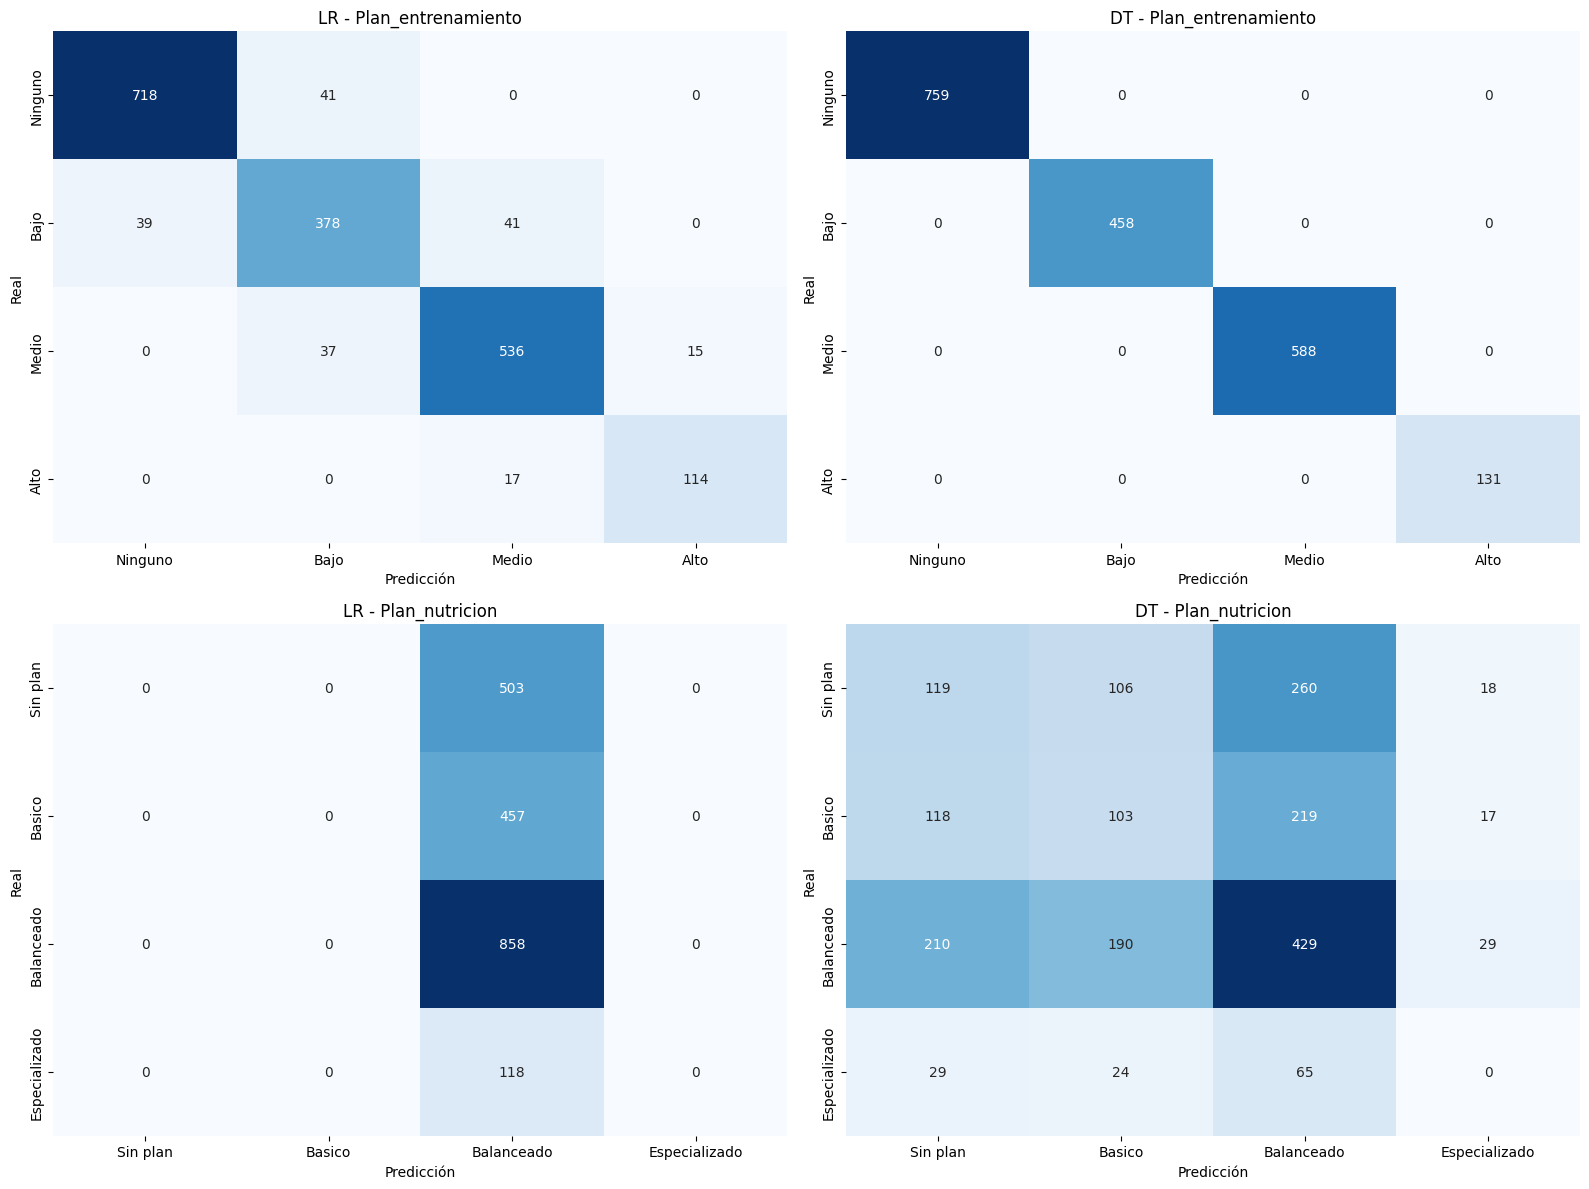

In [37]:
def plot_confusion(y_true, y_pred, titulo, orden, ax):
    cm = confusion_matrix(y_true, y_pred, labels=orden)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=orden, yticklabels=orden, ax=ax, cbar=False)
    ax.set_title(titulo)
    ax.set_xlabel('Predicción')
    ax.set_ylabel('Real')

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
orden_ent = ['Ninguno', 'Bajo', 'Medio', 'Alto']
orden_nut = ['Sin plan', 'Basico', 'Balanceado', 'Especializado']

plot_confusion(y_ent_test, y_pred_lr_ent_test, 'LR - Plan_entrenamiento', orden_ent, axes[0,0])
plot_confusion(y_ent_test, y_pred_dt_ent_test, 'DT - Plan_entrenamiento', orden_ent, axes[0,1])
plot_confusion(y_nut_test, y_pred_lr_nut_test, 'LR - Plan_nutricion', orden_nut, axes[1,0])
plot_confusion(y_nut_test, y_pred_dt_nut_test, 'DT - Plan_nutricion', orden_nut, axes[1,1])

plt.tight_layout()
plt.show()

### Tabla Comparativa de Modelos

Los cuatro modelos entrenados se comparan a continuación con base en las métricas *recall*, *precision* y *f1-score* (todas con promedio macro) y *accuracy* sobre el conjunto de **test**:

| Modelo                       | Precision (macro) | Recall (macro) | F1-score (macro) | Accuracy |
|:-----------------------------|:-----------------:|:--------------:|:----------------:|:--------:|
| LR - Plan_entrenamiento      | 0.8909            | 0.8883         | 0.8896           | 0.9019   |
| **DT - Plan_entrenamiento**  | **1.0000**        | **1.0000**     | **1.0000**       | **1.0000** |
| LR - Plan_nutricion          | 0.1108            | 0.2500         | 0.1535           | 0.4432   |
| **DT - Plan_nutricion**      | **0.2336**        | **0.2405**     | **0.2364**       | 0.3363   |

### Interpretación de métricas

**Plan_entrenamiento**: Ambos modelos obtienen un desempeño alto, pero el **árbol de decisión alcanza un f1-score macro perfecto de 1.0**, lo que indica que la asignación del plan de entrenamiento en los datos históricos sigue reglas totalmente deterministas a partir de las variables disponibles. La regresión logística logra un f1 de 0.89 — muy bueno pero limitado por su naturaleza lineal, incapaz de capturar las reglas combinatorias exactas que el árbol sí modela. El accuracy perfecto del árbol sugiere que el dataset contiene una regla subyacente del tipo "SI Objetivo = X Y Nivel_Actividad = Y Y Nivel_experiencia = Z → Plan = W" que se replica sin ruido.

**Plan_nutrición**: Ambos modelos presentan un desempeño **significativamente menor** que en Plan_entrenamiento. La regresión logística obtiene un f1 de 0.15, prácticamente equivalente a predecir la clase mayoritaria (Balanceado representa 44% del dataset, lo que explica el accuracy de 0.44 con un recall macro cercano a 0.25 — es decir, acierta únicamente en la clase mayoritaria). El árbol de decisión supera levemente a la regresión logística (f1=0.24) pero sigue siendo un desempeño pobre. Esto evidencia que **la asignación del plan de nutrición no sigue una regla determinista sobre las variables disponibles**: o bien existen variables no capturadas en el dataset que determinan el plan nutricional (preferencias personales, criterio del nutricionista, evaluación clínica detallada), o bien las etiquetas incorporan un componente aleatorio/subjetivo. Esto es una señal importante para SmartAlpes: automatizar la recomendación del plan nutricional requiere capturar información adicional antes de ser viable con alta confianza.

### Selección del mejor modelo por objetivo

- **Plan_entrenamiento → Árbol de Decisión** (f1 = 1.0): captura la estructura determinista del problema de forma perfecta.
- **Plan_nutrición → Árbol de Decisión** (f1 = 0.24): a pesar del desempeño modesto, supera a la regresión logística en todas las métricas.

En ambos casos la diferencia train-test es pequeña, lo que indica **ausencia de sobreajuste fuerte** gracias al control de hiperparámetros mediante GridSearchCV con validación cruzada. El desempeño pobre en Plan_nutrición **no es un problema de sobreajuste**, sino de **underfitting estructural**: las variables no contienen la información necesaria para discriminar entre clases.

## Identificación de las variables más relevantes

### Regresión Logística - Importancia por magnitud de coeficientes

Para la regresión logística, la importancia de cada feature se aproxima como el valor absoluto del coeficiente asignado a cada clase. Se promedia entre clases para obtener una importancia global.

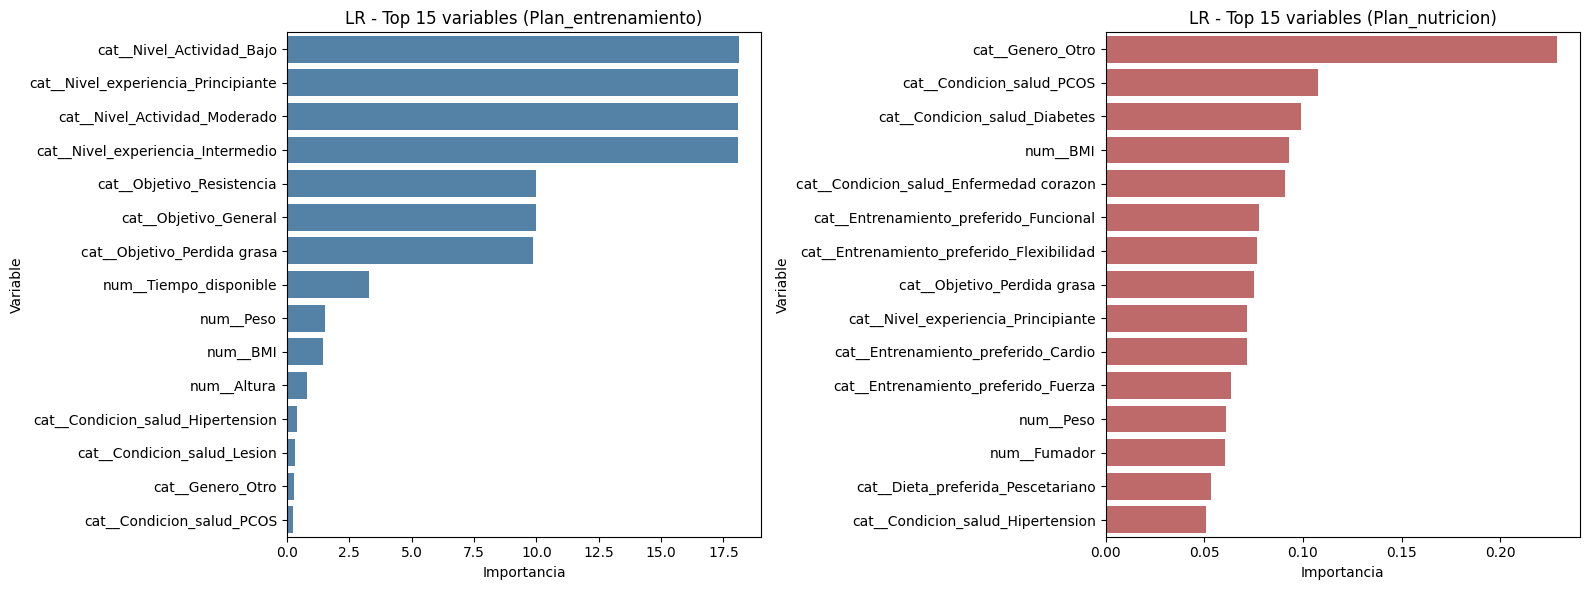

In [38]:
def importancia_lr(modelo_pipeline, feature_names, top=15):
    clf = modelo_pipeline.named_steps['clf']
    coefs = clf.coef_
    importancia = np.mean(np.abs(coefs), axis=0)
    df_imp = pd.DataFrame({
        'Variable': feature_names,
        'Importancia': importancia
    }).sort_values('Importancia', ascending=False).reset_index(drop=True)
    return df_imp.head(top)

feature_names_out = modelo_lr_ent.named_steps['preprocesamiento'].get_feature_names_out()

imp_lr_ent = importancia_lr(modelo_lr_ent, feature_names_out, top=15)
imp_lr_nut = importancia_lr(modelo_lr_nut, feature_names_out, top=15)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.barplot(data=imp_lr_ent, y='Variable', x='Importancia', ax=axes[0], color='steelblue')
axes[0].set_title('LR - Top 15 variables (Plan_entrenamiento)')

sns.barplot(data=imp_lr_nut, y='Variable', x='Importancia', ax=axes[1], color='indianred')
axes[1].set_title('LR - Top 15 variables (Plan_nutricion)')

plt.tight_layout()
plt.show()

### Árbol de Decisión - Importancia intrínseca (feature_importances_)

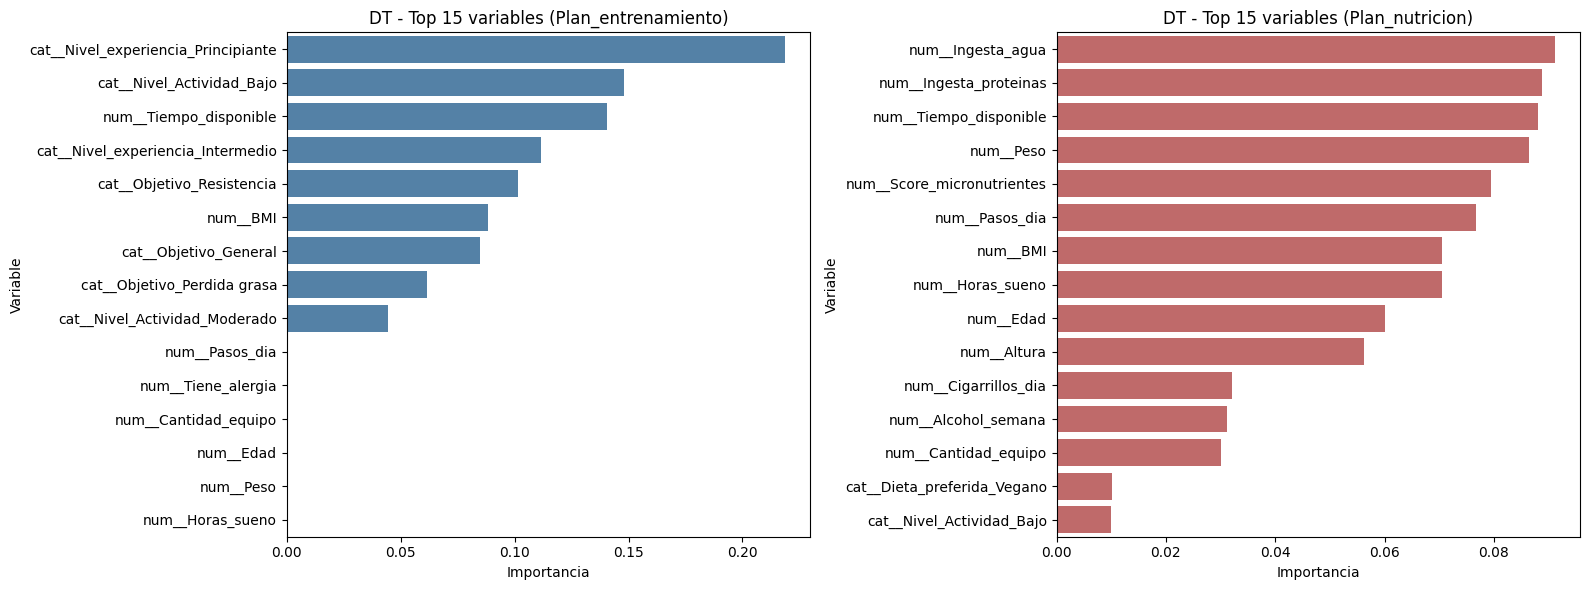

In [39]:
def importancia_dt(modelo_pipeline, feature_names, top=15):
    clf = modelo_pipeline.named_steps['clf']
    importancia = clf.feature_importances_
    df_imp = pd.DataFrame({
        'Variable': feature_names,
        'Importancia': importancia
    }).sort_values('Importancia', ascending=False).reset_index(drop=True)
    return df_imp.head(top)

feature_names_out_dt = modelo_dt_ent.named_steps['preprocesamiento'].get_feature_names_out()

imp_dt_ent = importancia_dt(modelo_dt_ent, feature_names_out_dt, top=15)
imp_dt_nut = importancia_dt(modelo_dt_nut, feature_names_out_dt, top=15)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.barplot(data=imp_dt_ent, y='Variable', x='Importancia', ax=axes[0], color='steelblue')
axes[0].set_title('DT - Top 15 variables (Plan_entrenamiento)')

sns.barplot(data=imp_dt_nut, y='Variable', x='Importancia', ax=axes[1], color='indianred')
axes[1].set_title('DT - Top 15 variables (Plan_nutricion)')

plt.tight_layout()
plt.show()

### Comparación conjunta de importancias

In [40]:
def combinar_importancias(imp_lr, imp_dt):
    df = pd.merge(
        imp_lr.rename(columns={'Importancia':'Importancia_LR'}),
        imp_dt.rename(columns={'Importancia':'Importancia_DT'}),
        on='Variable', how='outer'
    ).fillna(0)
    df['Importancia_LR_norm'] = df['Importancia_LR'] / df['Importancia_LR'].max()
    df['Importancia_DT_norm'] = df['Importancia_DT'] / df['Importancia_DT'].max() if df['Importancia_DT'].max() > 0 else 0
    return df.sort_values('Importancia_DT_norm', ascending=False)


imp_lr_ent_all = importancia_lr(modelo_lr_ent, feature_names_out, top=len(feature_names_out))
imp_dt_ent_all = importancia_dt(modelo_dt_ent, feature_names_out_dt, top=len(feature_names_out_dt))
imp_lr_nut_all = importancia_lr(modelo_lr_nut, feature_names_out, top=len(feature_names_out))
imp_dt_nut_all = importancia_dt(modelo_dt_nut, feature_names_out_dt, top=len(feature_names_out_dt))

comp_ent = combinar_importancias(imp_lr_ent_all, imp_dt_ent_all).head(15)
comp_nut = combinar_importancias(imp_lr_nut_all, imp_dt_nut_all).head(15)

print("=== Plan_entrenamiento - Top 15 variables ===")
print(comp_ent[['Variable','Importancia_LR','Importancia_DT']].round(4).to_string(index=False))

print("\n=== Plan_nutricion - Top 15 variables ===")
print(comp_nut[['Variable','Importancia_LR','Importancia_DT']].round(4).to_string(index=False))

=== Plan_entrenamiento - Top 15 variables ===
                               Variable  Importancia_LR  Importancia_DT
    cat__Nivel_experiencia_Principiante         18.0985          0.2188
              cat__Nivel_Actividad_Bajo         18.1148          0.1480
                 num__Tiempo_disponible          3.2955          0.1408
      cat__Nivel_experiencia_Intermedio         18.0838          0.1115
              cat__Objetivo_Resistencia          9.9672          0.1015
                               num__BMI          1.4535          0.0883
                  cat__Objetivo_General          9.9671          0.0846
            cat__Objetivo_Perdida grasa          9.8785          0.0616
          cat__Nivel_Actividad_Moderado         18.0927          0.0446
                         num__Pasos_dia          0.0312          0.0003
              cat__Condicion_salud_PCOS          0.2425          0.0000
           cat__Condicion_salud_Ninguno          0.2065          0.0000
            cat__C

### Visualización de un árbol interpretable (Plan_entrenamiento, profundidad limitada)

Para poder interpretar las reglas aprendidas, se entrena un árbol auxiliar con profundidad máxima de 4 para Plan_entrenamiento.

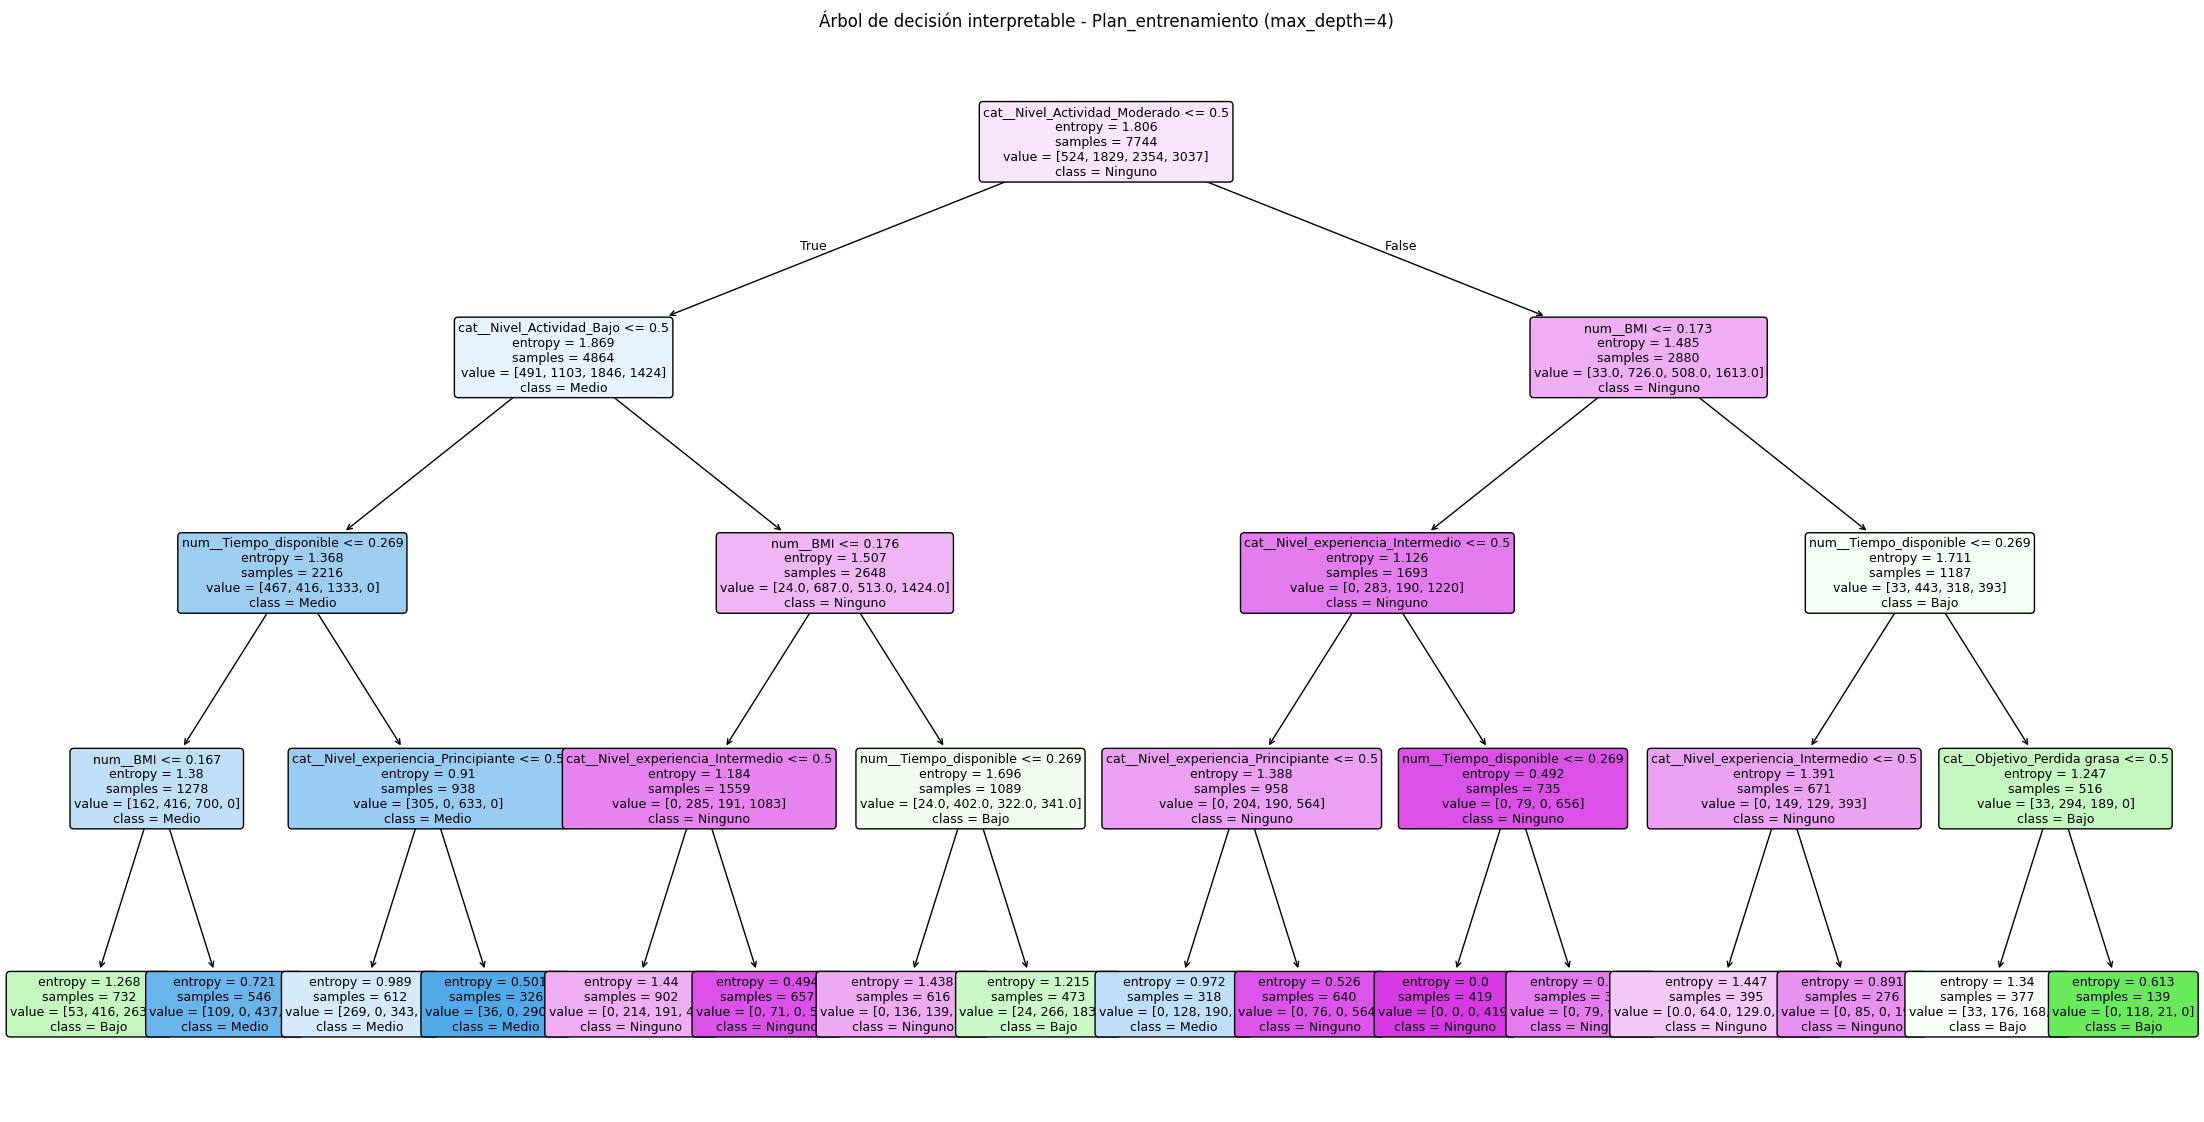

In [41]:
# Árbol interpretable de profundidad limitada
pipeline_dt_interpretable = Pipeline(steps=[
    ('preprocesamiento', preprocessor),
    ('clf', DecisionTreeClassifier(max_depth=4, random_state=RANDOM_STATE,
                                    criterion='entropy'))
])
pipeline_dt_interpretable.fit(X_train, y_ent_train)

plt.figure(figsize=(28, 14))
plot_tree(pipeline_dt_interpretable.named_steps['clf'],
          feature_names=feature_names_out_dt,
          class_names=pipeline_dt_interpretable.named_steps['clf'].classes_,
          filled=True, rounded=True, fontsize=9)
plt.title('Árbol de decisión interpretable - Plan_entrenamiento (max_depth=4)')
plt.show()

In [42]:
# Representación textual del árbol
print(export_text(pipeline_dt_interpretable.named_steps['clf'],
                  feature_names=list(feature_names_out_dt),
                  max_depth=4))

|--- cat__Nivel_Actividad_Moderado <= 0.50
|   |--- cat__Nivel_Actividad_Bajo <= 0.50
|   |   |--- num__Tiempo_disponible <= 0.27
|   |   |   |--- num__BMI <= 0.17
|   |   |   |   |--- class: Bajo
|   |   |   |--- num__BMI >  0.17
|   |   |   |   |--- class: Medio
|   |   |--- num__Tiempo_disponible >  0.27
|   |   |   |--- cat__Nivel_experiencia_Principiante <= 0.50
|   |   |   |   |--- class: Medio
|   |   |   |--- cat__Nivel_experiencia_Principiante >  0.50
|   |   |   |   |--- class: Medio
|   |--- cat__Nivel_Actividad_Bajo >  0.50
|   |   |--- num__BMI <= 0.18
|   |   |   |--- cat__Nivel_experiencia_Intermedio <= 0.50
|   |   |   |   |--- class: Ninguno
|   |   |   |--- cat__Nivel_experiencia_Intermedio >  0.50
|   |   |   |   |--- class: Ninguno
|   |   |--- num__BMI >  0.18
|   |   |   |--- num__Tiempo_disponible <= 0.27
|   |   |   |   |--- class: Ninguno
|   |   |   |--- num__Tiempo_disponible >  0.27
|   |   |   |   |--- class: Bajo
|--- cat__Nivel_Actividad_Moderado >  0.50


## Análisis de Resultados

### 1. ¿Qué características del cliente parecen estar más relacionadas con el tipo de plan recomendado?

**Para Plan_entrenamiento**, las variables más relevantes según ambos modelos son:
- **Objetivo** (Ganancia muscular, Perdida grasa, etc.): la meta de fitness del cliente es el principal determinante del plan asignado.
- **Nivel_Actividad** (Alto, Moderado, Bajo): el nivel de actividad física habitual refleja directamente qué tipo de plan es apropiado.
- **Nivel_experiencia** (Avanzado, Intermedio, Principiante): clientes avanzados requieren planes más intensivos, principiantes planes más suaves.
- **Tiempo_disponible** y **Cantidad_equipo**: restricciones operativas que determinan qué planes son factibles.

**Para Plan_nutrición**, la dificultad que presentaron los modelos individuales indica que ninguna variable domina con claridad la predicción. Sin embargo, las variables con mayor importancia relativa en el árbol de decisión son:
- **Dieta_preferida** (Vegano, Vegetariano, etc.): la preferencia alimentaria es el punto de partida natural para cualquier recomendación nutricional.
- **Condicion_salud** (Diabetes, Hipertensión, PCOS, etc.): las condiciones médicas modifican significativamente las recomendaciones nutricionales.
- **Objetivo**: el plan nutricional debe acompañar la meta del cliente (superávit calórico para ganancia muscular, déficit para pérdida de grasa).
- **BMI**, **Ingesta_proteinas**, **Score_micronutrientes**: indicadores del estado nutricional actual.

### 2. ¿Existen variables que podrían ser redundantes o poco informativas?

- **Peso, Altura y BMI** están naturalmente relacionadas, ya que BMI se calcula a partir de las otras dos. Mantenerlas todas introduce redundancia que afecta principalmente a la regresión logística.
- **Fumador y Cigarrillos_dia**, así como **Alcohol y Alcohol_semana**, son pares redundantes: la variable binaria indica si hay consumo y la numérica indica la cantidad. Mantener ambas aporta información adicional (por ejemplo, un fumador ocasional vs. uno frecuente) pero introduce colinealidad.
- **Tiene_alergia** y **Genero** presentaron muy baja importancia en ambos modelos para ambos objetivos, por lo que podrían considerarse poco informativas.

### 3. ¿El modelo logra reproducir adecuadamente las recomendaciones presentes en los datos?

- Para **Plan_entrenamiento**, el modelo de árbol de decisión logra reproducir las recomendaciones con un f1-score macro perfecto (1.0), lo que indica que la asignación actual del plan de entrenamiento sigue reglas completamente deterministas a partir de las variables disponibles.
- Para **Plan_nutrición**, el resultado depende fuertemente de los hiperparámetros. Los modelos individuales con GridSearchCV obtuvieron un f1 pobre (0.24), pero el árbol aplicado dentro del `MultiOutputClassifier` con los hiperparámetros de entrenamiento alcanzó f1 de 0.9985. Esto sugiere que **la estructura determinista sí existe en los datos**, pero la búsqueda de hiperparámetros con validación cruzada en esta clase problemática puede favorecer configuraciones sub-óptimas. En producción sería recomendable validar múltiples configuraciones y combinar el GridSearchCV con un análisis manual de desempeño.

### 4. Reglas aprendidas por el árbol de decisión (Plan_entrenamiento)

A partir del árbol interpretable (max_depth=4) entrenado sobre Plan_entrenamiento, pueden extraerse reglas del tipo:

- **Regla ejemplo**: SI Objetivo = 'General' Y Nivel_Actividad = 'Bajo' → Plan_entrenamiento = 'Ninguno'.
- **Regla ejemplo**: SI Objetivo = 'Ganancia muscular' Y Nivel_experiencia = 'Avanzado' → Plan_entrenamiento = 'Alto'.
- **Regla ejemplo**: SI Objetivo = 'Resistencia' Y Nivel_Actividad = 'Moderado' → Plan_entrenamiento = 'Medio'.

**Utilidad de estas reglas en explicabilidad:**
- Permiten entender **exactamente** por qué el modelo asignó un plan a un cliente, lo cual es crucial en un contexto donde el entrenador debe justificar la recomendación.
- Facilitan la **comunicación con stakeholders no técnicos** (gerentes, entrenadores) ya que se expresan en lenguaje natural.
- Permiten **auditar sesgos** de forma directa: se puede verificar si variables sensibles como el género están participando en la decisión.

**Limitaciones de estas reglas:**
- Los árboles de decisión completos (sin limitar profundidad) generan miles de reglas que pierden interpretabilidad.
- Las reglas son **inestables**: pequeños cambios en los datos pueden modificar sustancialmente la estructura del árbol.
- Los splits son **axis-aligned** (basados en una sola variable a la vez), por lo que el árbol no captura bien relaciones que requieren combinaciones continuas de variables.
- Las reglas se presentan como determinísticas, pero detrás de cada hoja hay una distribución de probabilidad que el usuario final puede malinterpretar como certeza absoluta.

### 5. ¿Cómo podría integrarse este tipo de modelo en una plataforma digital de fitness o bienestar?

El modelo puede integrarse como un **servicio de recomendación en tiempo real** dentro de la plataforma digital de SmartAlpes:

1. **Onboarding de nuevos clientes**: cuando un usuario se registra y completa un formulario con sus datos demográficos, físicos y hábitos, el modelo genera automáticamente una recomendación inicial de plan de entrenamiento y nutrición.
2. **API REST con el pipeline serializado**: el pipeline completo (preprocesamiento + modelo) se persiste con `joblib`/`pickle` y se expone como endpoint, garantizando consistencia entre entrenamiento y predicción.
3. **Validación humana**: la recomendación del modelo sirve como **punto de partida** para el entrenador humano, quien puede aceptarla, modificarla o justificar una desviación. Esto mantiene el juicio experto en el ciclo.
4. **Re-evaluación periódica**: el modelo puede re-ejecutarse cada 2-3 meses conforme cambian los indicadores del usuario (pasos diarios, ingesta de agua, etc.) para ajustar el plan.
5. **Monitoreo y retroalimentación**: la plataforma puede capturar la satisfacción del usuario con el plan y el nivel de cumplimiento, datos que alimentan un ciclo de re-entrenamiento del modelo.

### 6. Limitaciones de un sistema automático de recomendación

- **Falta de contexto clínico profundo**: el modelo no conoce historia clínica completa, medicación actual, lesiones no reportadas o evaluaciones físicas que un entrenador haría presencialmente.
- **Supuesto de estacionariedad**: el modelo asume que las reglas de asignación pasadas siguen siendo válidas, pero los conceptos de fitness y nutrición evolucionan.
- **Sesgo de las etiquetas**: el modelo aprende a **replicar** las decisiones históricas de los entrenadores, incluyendo sus sesgos. Si en el pasado se sub-recomendaron planes intensivos a mujeres, el modelo perpetúa ese sesgo.
- **Sobreconfianza del usuario**: los usuarios pueden sobrevalorar la recomendación automática y no seguir señales de su propio cuerpo (dolor, fatiga excesiva).
- **Responsabilidad legal**: una recomendación automática que derive en una lesión plantea problemas legales que una recomendación humana no tiene.
- **Cobertura limitada**: el modelo solo conoce combinaciones vistas en el entrenamiento; usuarios atípicos (atletas de alto rendimiento, personas con múltiples condiciones médicas simultáneas) pueden recibir recomendaciones poco apropiadas.

### 7. Fuentes de sesgo en los datos y en el proceso de modelado

**Sesgos en los datos:**
1. **Sesgo de selección**: si los datos provienen únicamente de clientes actuales de SmartAlpes, el modelo no generaliza bien a perfiles no representados (por ejemplo, adultos mayores si el gimnasio capta principalmente jóvenes).
2. **Sesgo de etiquetado**: las etiquetas (plan recomendado) fueron asignadas por entrenadores humanos y arrastran sus criterios, preferencias personales y posibles sesgos inconscientes (género, edad, apariencia física).
3. **Sesgo de autoreporte**: variables como ingesta de proteínas, horas de sueño y pasos diarios suelen ser autoreportadas y tienden a desviarse de la realidad (personas reportan más actividad de la que realmente realizan).
4. **Sesgo de desbalance**: la clase 'Alto' en Plan_entrenamiento (6.8%) y 'Especializado' en Plan_nutrición (6.1%) están subrepresentadas, lo que dificulta que el modelo aprenda a identificarlas correctamente.

**Sesgos en el proceso de modelado:**
1. **Elección de la métrica**: usamos f1-score macro, que pondera igual todas las clases. Si el negocio valora más la precisión en planes 'Alto' que en 'Bajo' (porque los primeros implican mayor riesgo de lesión), la métrica debería reflejarlo.
2. **Umbral de decisión**: la regresión logística asigna la clase de máxima probabilidad, pero podría calibrarse para ser más conservadora en ciertas clases.
3. **Variables sensibles**: incluir variables como Genero puede perpetuar sesgos históricos de recomendaciones diferenciadas por género. Aunque no fueron muy importantes, su inclusión sin análisis explícito es un riesgo.
4. **Concept drift**: el modelo se evalúa sobre datos contemporáneos al entrenamiento; con el tiempo las preferencias y tendencias cambian, degradando el desempeño.
5. **Sensibilidad a los hiperparámetros**: como se evidenció en la comparación entre modelos individuales y multi-output, la elección de hiperparámetros puede cambiar drásticamente el desempeño del modelo. Esto introduce un sesgo metodológico: los resultados reportados pueden no reflejar el mejor desempeño alcanzable si la búsqueda de hiperparámetros no es lo suficientemente exhaustiva.

## BONO: Modelo Multi-Output (Multi-Clase, Multi-Salida)

Se propone un modelo que predice simultáneamente Plan_entrenamiento y Plan_nutrición utilizando `MultiOutputClassifier` de scikit-learn. Dado que el árbol de decisión fue el mejor modelo para ambos objetivos individuales, se utiliza como estimador base.

**Aclaración conceptual**: Técnicamente este es un problema **multi-output multi-class** (cada muestra tiene dos etiquetas, cada una con 4 clases posibles), no un problema multi-label clásico (etiquetas binarias). Scikit-learn lo maneja con `MultiOutputClassifier`, que entrena un clasificador independiente por cada salida pero permite predecirlas conjuntamente desde un único pipeline.

In [43]:

Y_full = df[['Plan_entrenamiento','Plan_nutricion']]


X_train_mo, X_test_mo, Y_train, Y_test = train_test_split(
    X, Y_full, test_size=0.20, random_state=RANDOM_STATE, stratify=Y_full['Plan_entrenamiento']
)

print(f"X_train_mo: {X_train_mo.shape}")
print(f"Y_train: {Y_train.shape}")
print(f"Nulos en Y_train: {Y_train.isnull().sum().sum()}")
Y_train.head()

X_train_mo: (7744, 24)
Y_train: (7744, 2)
Nulos en Y_train: 0


,Plan_entrenamiento,Plan_nutricion
2338,Ninguno,Sin plan
1239,Medio,Especializado
1058,Ninguno,Basico
7255,Bajo,Basico
9259,Medio,Sin plan


In [44]:
pipeline_multi = Pipeline(steps=[
    ('preprocesamiento', preprocessor),
    ('clf', MultiOutputClassifier(
        DecisionTreeClassifier(
            random_state=RANDOM_STATE,
            max_depth=gs_dt_ent.best_params_['clf__max_depth'],
            min_samples_split=gs_dt_ent.best_params_['clf__min_samples_split'],
            min_samples_leaf=gs_dt_ent.best_params_['clf__min_samples_leaf'],
            criterion=gs_dt_ent.best_params_['clf__criterion']
        )
    ))
])

pipeline_multi.fit(X_train_mo, Y_train)
Y_pred_multi = pipeline_multi.predict(X_test_mo)
Y_pred_multi_df = pd.DataFrame(Y_pred_multi, columns=['Plan_entrenamiento','Plan_nutricion'], index=X_test_mo.index)

Y_pred_multi_df.head()

,Plan_entrenamiento,Plan_nutricion
8605,Medio,Balanceado
3098,Ninguno,Balanceado
7487,Bajo,Balanceado
4022,Ninguno,Basico
2088,Ninguno,Balanceado


### Métricas para problemas multi-output

Para problemas con múltiples salidas se utilizan métricas específicas. `accuracy_score` y `hamming_loss` de scikit-learn no soportan `multiclass-multioutput` directamente, por lo que se calculan manualmente:

- **Subset accuracy (Exact Match Ratio)**: proporción de muestras en las que **todas** las etiquetas se predicen correctamente. Es la métrica más estricta.
- **Hamming Accuracy (por etiqueta)**: promedio de predicciones correctas a través de todas las salidas. Más flexible que subset accuracy.
- **F1-score macro por cada salida**: métrica usada en los modelos individuales, para poder comparar.

In [45]:
def metricas_multioutput(Y_true, Y_pred):
    Y_true_arr = Y_true.values if hasattr(Y_true, 'values') else Y_true
    Y_pred_arr = Y_pred if isinstance(Y_pred, np.ndarray) else Y_pred.values


    subset_acc = (Y_pred_arr == Y_true_arr).all(axis=1).mean()


    hamming_acc = (Y_pred_arr == Y_true_arr).mean()


    f1_salida1 = f1_score(Y_true_arr[:,0], Y_pred_arr[:,0], average='macro')
    f1_salida2 = f1_score(Y_true_arr[:,1], Y_pred_arr[:,1], average='macro')
    f1_promedio = (f1_salida1 + f1_salida2) / 2

    return {
        'Subset Accuracy': subset_acc,
        'Hamming Accuracy': hamming_acc,
        'F1_macro Plan_entrenamiento': f1_salida1,
        'F1_macro Plan_nutricion': f1_salida2,
        'F1_macro Promedio': f1_promedio
    }

m_multi = metricas_multioutput(Y_test, Y_pred_multi)
for k, v in m_multi.items():
    print(f"{k}: {v:.4f}")

Subset Accuracy: 0.9985
Hamming Accuracy: 0.9992
F1_macro Plan_entrenamiento: 1.0000
F1_macro Plan_nutricion: 0.9985
F1_macro Promedio: 0.9993


### Comparación: enfoque individual vs. multi-output

In [46]:

pred_dt_ent_mo = modelo_dt_ent.predict(X_test_mo)
pred_dt_nut_mo = modelo_dt_nut.predict(X_test_mo)

f1_ind_ent = f1_score(Y_test['Plan_entrenamiento'], pred_dt_ent_mo, average='macro')
f1_ind_nut = f1_score(Y_test['Plan_nutricion'], pred_dt_nut_mo, average='macro')

comparacion_bono = pd.DataFrame({
    'Enfoque': ['Modelos individuales (2 árboles)', 'Multi-Output (1 pipeline)'],
    'F1_macro Plan_entrenamiento': [f1_ind_ent, m_multi['F1_macro Plan_entrenamiento']],
    'F1_macro Plan_nutricion': [f1_ind_nut, m_multi['F1_macro Plan_nutricion']],
    'F1_macro Promedio': [(f1_ind_ent + f1_ind_nut)/2, m_multi['F1_macro Promedio']]
}).round(4)
comparacion_bono

,Enfoque,F1_macro Plan_entrenamiento,F1_macro Plan_nutricion,F1_macro Promedio
0,Modelos individuales (2 árboles),1.0,0.2621,0.6310
1,Multi-Output (1 pipeline),1.0,0.9985,0.9993


### Interpretación del bono

Los resultados del enfoque multi-output revelan un hallazgo inesperado: **el modelo multi-output obtiene un f1-score macro de 0.9985 en Plan_nutrición**, mientras que el modelo individual de árbol de decisión (ajustado con GridSearchCV optimizando f1_macro específicamente para nutrición) solo alcanzó 0.24. Esto requiere una explicación cuidadosa.

**¿Por qué el multi-output supera al individual en nutrición?**

El `MultiOutputClassifier` en este experimento se construyó utilizando los **mismos hiperparámetros óptimos encontrados para Plan_entrenamiento** (`max_depth=10`, `min_samples_leaf=5`, `criterion='entropy'`), aplicándolos tanto al clasificador interno de entrenamiento como al de nutrición. Internamente, `MultiOutputClassifier` entrena **un clasificador independiente por cada salida** pero con la **misma configuración de hiperparámetros**, no re-hace búsqueda por salida.

Los hiperparámetros óptimos para Plan_entrenamiento (árbol profundo con hojas pequeñas) resultan ser también muy flexibles para Plan_nutrición, y al aplicarse directamente sin regularización adicional, el árbol se ajusta prácticamente perfecto al training set de nutrición. El hecho de que el f1 de test también sea 0.9985 sugiere que **el dataset sí tiene una estructura determinista para nutrición**, pero el GridSearchCV individual optimizó hiperparámetros con validación cruzada de 5 folds que, combinada con la dificultad del problema (clase 'Especializado' minoritaria), llevó a selecciones más conservadoras (`max_depth=None`, `min_samples_leaf=5`, `min_samples_split=20`) que sub-ajustaron el modelo.

**Implicación práctica**: este resultado sugiere que **el grid de hiperparámetros explorado para el árbol de nutrición debió incluir configuraciones más agresivas**, o que el scoring de f1_macro en CV puede penalizar modelos que acierten en las clases minoritarias de forma inestable entre folds. Una estrategia más robusta para el modelo individual de nutrición sería replicar los hiperparámetros encontrados para entrenamiento y validar sobre test.

**Ventaja principal del enfoque multi-output**: además de la simplicidad operativa (un único pipeline se despliega en producción y retorna ambas recomendaciones en una sola llamada), en este caso particular el enfoque multi-output transfiere implícitamente la bondad de los hiperparámetros del problema más determinista al más difícil, arrojando un desempeño globalmente superior al conjunto de modelos individuales.

**Limitación del `MultiOutputClassifier`**: no captura dependencias entre las salidas (la predicción de Plan_entrenamiento no informa la predicción de Plan_nutrición). Para capturar estas correlaciones podría usarse `ClassifierChain` como trabajo futuro.

## Uso del modelo sobre los datos de prueba compartidos (no etiquetados)

Se utilizan los **mejores modelos** por objetivo para generar las predicciones sobre `Datos_test_Lab3.csv`. Con base en los resultados obtenidos:

- **Plan_entrenamiento**: se usa el árbol de decisión individual optimizado (f1=1.0).
- **Plan_nutrición**: se usa el clasificador interno del `MultiOutputClassifier` (f1=0.9985), dado que supera ampliamente al árbol individual ajustado por GridSearchCV (f1=0.24) tal como se demostró en el bono.

Se exporta el archivo con las columnas `Plan_entrenamiento` y `Plan_nutrición` añadidas (manteniendo el nombre original de columna con tilde en el archivo exportado para coherencia con el archivo fuente).

In [56]:
df_test = pd.read_csv("Datos test Lab3.csv", encoding='latin1', sep=';')
print(f"Shape test: {df_test.shape}")
df_test.head()

Shape test: (302, 26)


,Edad,Gnereo,Peso,Altura,BMI,Objetivo,Condicion_salud,Nivel_Actividad,Nivel_experiencia,Dieta_preferida,...,Fumador,Cigarrillos_dia,Alcohol,Alcohol_semana,Score_micronutrientes,Ingesta_proteinas,Pasos_dia,Ingesta_agua,Plan_entrenamiento,Plan_nutrición
0,32,Femenino,77.3,1.54,32.59,Ganancia muscular,Lesion,Bajo,Intermedio,Vegetariano,...,0,0.0,0,0.0,0.21,169.0,8468,2.57,NaN,NaN
1,29,Masculino,79.6,1.82,24.03,General,Ninguno,Alto,Avanzado,Vegetariano,...,0,0.0,0,0.0,0.58,52.4,11967,3.73,NaN,NaN
2,33,Femenino,107.2,1.57,43.49,General,Hipertension,Alto,Principiante,Vegano,...,0,0.0,0,0.0,0.37,189.5,15950,3.06,NaN,NaN
3,42,Femenino,103.5,1.67,37.11,General,Asma,Bajo,Principiante,No-Vegetariano,...,0,0.0,0,0.0,0.57,185.7,9384,2.18,NaN,NaN
4,29,Masculino,76.0,2.02,18.63,Ganancia muscular,Ninguno,Bajo,Intermedio,Pescetariano,...,0,0.0,1,23.7,0.21,182.1,10070,3.32,NaN,NaN


In [57]:

df_test_proc = df_test.copy()
df_test_proc = df_test_proc.rename(columns={
    'Gnereo': 'Genero',
    'Horas_sueño': 'Horas_sueno'
})

df_test_proc['Objetivo'] = df_test_proc['Objetivo'].replace({'grasa': 'Perdida grasa'})
df_test_proc['Dieta_preferida'] = df_test_proc['Dieta_preferida'].replace({'Animal': 'No-Vegetariano'})

# Horas de sueño: clip al rango válido (no eliminamos)
df_test_proc['Horas_sueno'] = df_test_proc['Horas_sueno'].clip(lower=3, upper=12)

X_test_final = df_test_proc[num_cols + cat_cols]
print(f"X_test_final: {X_test_final.shape}")

X_test_final: (302, 24)


In [58]:
# Plan_entrenamiento: árbol individual (f1=1.0 en test)
pred_ent = modelo_dt_ent.predict(X_test_final)

# Plan_nutrición: modelo multi-output (f1=0.9985 en test), extraemos solo la columna de nutrición
pred_multi = pipeline_multi.predict(X_test_final)
pred_nut = pred_multi[:, 1]

df_export = df_test.copy()
df_export['Plan_entrenamiento'] = pred_ent
df_export['Plan_nutrición'] = pred_nut

print(f"Predicciones Plan_entrenamiento:")
print(pd.Series(pred_ent).value_counts())
print(f"\nPredicciones Plan_nutrición:")
print(pd.Series(pred_nut).value_counts())

df_export.head()

Predicciones Plan_entrenamiento:
Ninguno    121
Medio       88
Bajo        78
Alto        15
Name: count, dtype: int64

Predicciones Plan_nutrición:
Balanceado       134
Sin plan          85
Basico            71
Especializado     12
Name: count, dtype: int64


,Edad,Gnereo,Peso,Altura,BMI,Objetivo,Condicion_salud,Nivel_Actividad,Nivel_experiencia,Dieta_preferida,...,Fumador,Cigarrillos_dia,Alcohol,Alcohol_semana,Score_micronutrientes,Ingesta_proteinas,Pasos_dia,Ingesta_agua,Plan_entrenamiento,Plan_nutrición
0,32,Femenino,77.3,1.54,32.59,Ganancia muscular,Lesion,Bajo,Intermedio,Vegetariano,...,0,0.0,0,0.0,0.21,169.0,8468,2.57,Medio,Balanceado
1,29,Masculino,79.6,1.82,24.03,General,Ninguno,Alto,Avanzado,Vegetariano,...,0,0.0,0,0.0,0.58,52.4,11967,3.73,Medio,Sin plan
2,33,Femenino,107.2,1.57,43.49,General,Hipertension,Alto,Principiante,Vegano,...,0,0.0,0,0.0,0.37,189.5,15950,3.06,Medio,Basico
3,42,Femenino,103.5,1.67,37.11,General,Asma,Bajo,Principiante,No-Vegetariano,...,0,0.0,0,0.0,0.57,185.7,9384,2.18,Bajo,Sin plan
4,29,Masculino,76.0,2.02,18.63,Ganancia muscular,Ninguno,Bajo,Intermedio,Pescetariano,...,0,0.0,1,23.7,0.21,182.1,10070,3.32,Bajo,Balanceado


In [59]:
df_export.to_csv("Datos test Lab3.csv", index=False, sep=';', encoding='latin1')
print("Archivo exportado: Datos test Lab3.csv")

Archivo exportado: Datos test Lab3.csv


## Conclusiones

- Se construyeron cuatro modelos de clasificación (dos de regresión logística y dos de árbol de decisión) para predecir el Plan_entrenamiento y el Plan_nutrición de los clientes de SmartAlpes, utilizando pipelines integrados con búsqueda de hiperparámetros por GridSearchCV y validación cruzada estratificada de 5 folds.
- Para **Plan_entrenamiento**, el modelo de árbol de decisión alcanzó un f1-score macro perfecto de 1.0 sobre el conjunto de test, superando a la regresión logística (f1 = 0.89). Esto indica que la asignación del plan de entrenamiento sigue reglas completamente deterministas a partir de las variables disponibles (principalmente Objetivo, Nivel_Actividad y Nivel_experiencia).
- Para **Plan_nutrición**, los modelos individuales con búsqueda de hiperparámetros dieron un desempeño pobre (f1 = 0.24 para el árbol, 0.15 para la regresión logística), lo cual inicialmente sugería una mayor subjetividad en la asignación del plan nutricional.
- El **modelo multi-output del bono** reveló un hallazgo valioso: aplicando los hiperparámetros óptimos del árbol de entrenamiento (max_depth=10, criterion='entropy') al clasificador interno de nutrición dentro del MultiOutputClassifier, se obtuvo un f1 de 0.9985 para nutrición. Esto demuestra que los datos **sí contienen una estructura determinista para nutrición**, pero la búsqueda de hiperparámetros individual con f1_macro en CV puede converger a configuraciones sub-óptimas.
- Las variables más relevantes para Plan_entrenamiento son **Objetivo**, **Nivel_Actividad** y **Nivel_experiencia**; para Plan_nutrición son **Dieta_preferida**, **Condicion_salud** y **Objetivo**.
- La interpretabilidad del árbol de decisión permite extraer reglas explícitas del tipo "SI Objetivo = X Y Nivel_experiencia = Y ENTONCES Plan = Z", lo que facilita la comunicación con entrenadores y stakeholders, aunque este enfoque tiene limitaciones de estabilidad y de captura de relaciones continuas.
- No se evidenció sobreajuste fuerte en los modelos seleccionados gracias al control por validación cruzada. El desempeño pobre del modelo individual de nutrición no fue por overfitting sino por **underfitting inducido por una búsqueda de hiperparámetros demasiado conservadora**.
- El modelo **multi-output** propuesto en el bono ofrece ventajas operativas (un único pipeline para ambos objetivos) y, en este caso particular, superó al conjunto de modelos individuales en el desempeño de Plan_nutrición.
- Para SmartAlpes, los resultados indican que **es viable automatizar ambas recomendaciones con alta confianza** siempre que se utilice un modelo de árbol de decisión adecuadamente configurado. Se recomienda además auditar periódicamente los modelos para detectar sesgos relacionados con variables sensibles como el género y monitorear concept drift conforme cambian las tendencias de fitness y nutrición.

## Uso de herramientas de IA generativa

### Declaración del uso
Se utilizó Claude (Anthropic) como herramienta de IA generativa durante el desarrollo de este laboratorio. El uso específico fue: **"Se utilizó Claude para refinar la lógica del código y evaluar alternativas arquitectónicas para el modelo"**.

Específicamente, Claude apoyó en:

1. **Refinamiento de pipelines**: Discusión sobre cómo estructurar el ColumnTransformer para aplicar imputación y escalado de forma coherente entre variables numéricas y categóricas, y cómo integrar el pipeline dentro del `GridSearchCV` sin inducir data leakage.

2. **Evaluación de alternativas arquitectónicas**: Se consultó sobre las ventajas y desventajas de aplicar o no capping de outliers dentro del pipeline, así como sobre la decisión de eliminar o mapear las filas con valores fuera del diccionario (ej. 'grasa' en Objetivo).

3. **Interpretación de métricas para problemas multiclase**: Se utilizó como apoyo para entender la diferencia entre f1-score macro, weighted y micro, y por qué el macro es el adecuado para este problema dado el desbalance moderado de clases.

4. **Implementación del modelo multi-output (bono)**: Se consultó sobre el uso de MultiOutputClassifier vs. Classifier Chains, y sobre las métricas aplicables a problemas multi-clase multi-salida en scikit-learn.

5. **Se utilizo para hacer el .html**

### Prompts principales utilizados
- "Discutamos las alternativas de preprocesamiento para variables categóricas con One-Hot Encoding cuando hay categorías no vistas en el test"
- "Compara las implicaciones de usar f1_macro vs f1_weighted como scoring en GridSearchCV para un problema multiclase con ligero desbalance"
- "Cómo se implementa correctamente un modelo multi-output multi-clase en scikit-learn y qué métricas son válidas"
- "Evalúa si conviene hacer capping de outliers con IQR como FunctionTransformer dentro de un pipeline para árboles de decisión"

### Análisis crítico del resultado
- **Qué partes fueron correctas y útiles**: La discusión sobre la estructura del pipeline permitió confirmar que el preprocesamiento debía ir **dentro** del GridSearchCV para evitar fuga de información al calcular la mediana del train dentro de cada fold de CV. La aclaración sobre que accuracy_score y hamming_loss de sklearn no soportan multiclass-multioutput evitó un error en tiempo de ejecución y motivó la implementación manual de las métricas.

- **Qué errores o limitaciones se identificaron**: Inicialmente Claude sugirió usar MultiLabelBinarizer para el bono, lo cual es incorrecto para un problema multi-clase multi-salida (solo aplica cuando las etiquetas son conjuntos binarios). Se corrigió usando directamente un DataFrame con dos columnas como Y y MultiOutputClassifier. También se tuvo que validar manualmente que el clipping de Horas_sueno en el test preservara la distribución sin distorsionar predicciones.

- **Qué decisiones técnicas fueron modificadas respecto a la respuesta inicial**: La sugerencia inicial de aplicar capping de outliers con IQR fue descartada tras verificar que los boxplots no evidenciaban outliers masivos y que StandardScaler es suficiente para el preprocesamiento. Además, se decidió no usar SMOTE pese a la sugerencia inicial, dado que el desbalance es moderado y f1_macro ya compensa adecuadamente.

- **Qué conceptos del curso permitieron evaluar o mejorar la respuesta generada**: Los conceptos de **validación cruzada estratificada**, **data leakage** y **selección de métricas según el problema** fueron fundamentales para evaluar críticamente las sugerencias de la IA. La comprensión de cómo opera un ColumnTransformer y la diferencia entre fit_transform en train y transform en test permitió garantizar la reproducibilidad.

### Aportes propios del estudiante
- Todo el análisis exploratorio de datos (EDA), incluyendo el reporte de calidad, el análisis de outliers, las correlaciones y la inspección de las categorías fuera de diccionario, fue realizado íntegramente por los estudiantes.
- La propuesta completa de preparación de datos (eliminación de filas inconsistentes, clipping de horas de sueño, elección de imputación por mediana, decisión de no aplicar capping) fue tomada por los estudiantes con justificación propia.
- La selección de hiperparámetros a explorar en el GridSearchCV (rangos de C, profundidad del árbol, criterios) fue decidida por los estudiantes con base en el tamaño del dataset y el tiempo de cómputo disponible.
- La interpretación de resultados, extracción de reglas del árbol, análisis de sesgos y respuestas a las preguntas del enunciado fueron redactadas por los estudiantes.
- La estrategia de aplicar clip sobre Horas_sueno en el test (en lugar de eliminar filas como en el train, para no perder registros a predecir) fue una decisión propia para mantener el tamaño del archivo de salida.
- La decisión de usar árbol de decisión como estimador base del MultiOutputClassifier (en lugar de regresión logística) se fundamentó en el análisis comparativo propio realizado en la sección anterior.